Processing and Df creation
===

In [2]:
import pandas as pd
import scipy
import os
import math
import logging
import pathlib
import yaml
import zarr
import h5py
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import scipy.stats as stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from numpy import typing as npt
from typing import TYPE_CHECKING
from typing import Any
from tqdm import tqdm

## --> File path definitions

In [5]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.03.01"
sel_rec = 'allego_5__uid0301-16-46-48'




full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

# Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

# Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.03.01\allego_5__uid0301-16-46-48
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.03.01\allego_5__uid0301-16-46-48

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.03.01\allego_5__uid0301-16-46-48\allego_5__uid0301-16-46-48_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.03.01\allego_5__uid0301-16-46-48
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.03.01\allego_5__uid0301-16-46-48\allego_5__uid0301-16-46-48_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.03.01\allego_5__uid0301-16

## --> Loading the data

Mapping de l'électrode: [[11  4  8 13 10  6  9 12]
 [14  1  2  3 15  5  0  7]
 [30 22 28 29 26 27 24 31]
 [25 16 20 18 23 17 19 21]]

Fréquence d'échantillonnage : 1000.0 Hz


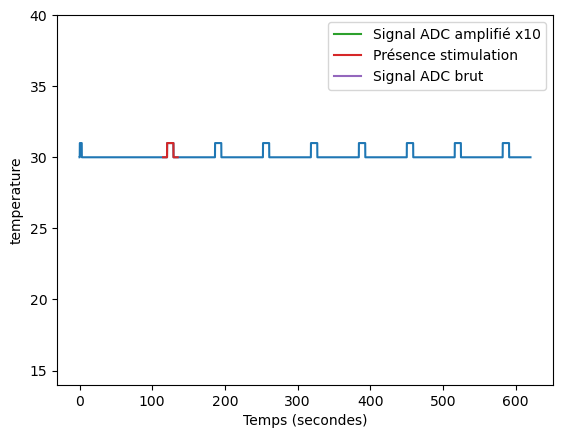


 hdf5 results file path : [WindowsPath('U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus/2024.03.01/allego_5__uid0301-16-46-48/allego_5__uid0301-16-46-48_spy/allego_5__uid0301-16-46-48_spy.result.hdf5')]

nombre de cluster tot : 112
Cluster IDs valides : [1, 8, 11, 12, 14, 15, 16, 18, 19, 20, 22, 23, 26, 27, 28, 31, 32, 34, 35, 36, 43, 44, 51, 61, 68, 77, 79, 82, 83, 87, 89, 92, 94, 96, 97, 99, 103]
Neurones valides par shank : {'sh#0': [1, 20, 51], 'sh#1': [22, 23, 26, 27, 28, 43, 44, 61, 77, 87, 89, 92, 94], 'sh#2': [8, 11, 31, 32, 34, 35, 68, 79, 82, 83, 96, 97], 'sh#3': [12, 14, 15, 16, 18, 19, 36, 99, 103]}

Liste timing stim :

Stimulus 1:
Début du stimulus: 120.356s
Fin du stimulus: 129.138s
Phase descendante: Début = 120.356s, Fin = 126.89s
Phase ascendante: Début = 126.89s, Fin = 120.937s
--------------------------------------------------

Liste timing stim :

Stimulus 2:
Début du stimulus: 186.347s
Fin du stimulus: 195.029s
Phase descendante: 

In [6]:
####### LFPs + ADCs from zarr #######



mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
print("Mapping de l'électrode:", mapping)


lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]


srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
print(f"\nFréquence d'échantillonnage : {srate_acq} Hz")


np.sum(adcs[0,:]>3.) > t_lfps.size/2

plt.plot(t_lfps, 30 + stim_present)
plt.plot(t_lfps, 10 * adcs[0,:])


select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

plt.plot(t_lfps[select_times], 10 * adcs[0, select_times], label="Signal ADC amplifié x10")
plt.plot(t_lfps[select_times], 30 + stim_present[select_times], label="Présence stimulation")
plt.plot(t_lfps[select_times], adcs[0, select_times], label="Signal ADC brut")

plt.ylim([14, 40])
plt.xlabel("Temps (secondes)")
plt.ylabel("temperature")
plt.legend()
plt.show()



####### Sampling rate for acquisition #######



f_sample_raw = 30000.0



####### Création du dataset pour spiketimes et amplitudes #######



dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")

print(f'\n hdf5 results file path : {merged}')



####### Selection des neurones valides #######



# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# Afficher les résultats
print(f"\nnombre de cluster tot :", len (clusinfo_df.loc[clusinfo_df['cluster_id']]))
print("Cluster IDs valides :", valid_all)
print("Neurones valides par shank :", valid_per_sh)



####### Here we infer the temperature timecourse #######

# 1. Auxiliary channel zero contains the temperature time course, up to a conversion factor (that is 10.0)
# 2. We infer it from auxiliary channel one, which takes value one when temperature changes and zero otherwise. 
#    In this case we also need the temperature profile file



if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]



def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    # n_stims = np.sum(valid_up)
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end



t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp46_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)




####### Infer ascending and descending phases #######



thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

    # Affichage des résultats pour chaque stimulus
    print("\nListe timing stim :")
    print(f"\nStimulus {i + 1}:")
    print(f"Début du stimulus: {t_stim_start[i]}s")
    print(f"Fin du stimulus: {t_stim_end[i]}s")
    print(f"Phase descendante: Début = {t_stim_start[i]}s, Fin = {descending_end[i]}s")
    print(f"Phase ascendante: Début = {ascending_start[i]}s, Fin = {ascending_end[i]}s")
    print('-' * 50)  # Séparation entre les stimuli



# ####### Parameters for the PSTH #######



win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus



####### Définir les périodes pour chaque stimulus #######



print('\nTemps des periodes de chaque stim :')

time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

    # Affichage des périodes définies pour chaque stimulus
    print(f"\nStimulus {i + 1}:")
    print(f"Baseline : Début = {baseline_start}s, Fin = {baseline_end}s")
    print(f"Stim : Début = {stim_start}s, Fin = {stim_end}s")
    print(f"Post-Stim : Début = {post_stim_start}s, Fin = {post_stim_end}s")
    print('-' * 50)




# --> Loadind data without TTL for temperature

In [ ]:
# ####### LFPs + ADCs from zarr #######



# mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
# print("Mapping de l'électrode:", mapping)


# lfps = ephys_res["lfps/channels/1"][:]
# lfps -= np.median(lfps, axis=0)
# adcs = ephys_res["lfps/adcs/1"][:]
# stim_present = (adcs[1,:] > 1).astype(int)
# t_lfps = ephys_res["lfps/timestamps/1"][:]


# srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
# print(f"\nFréquence d'échantillonnage : {srate_acq} Hz")


# np.sum(adcs[0,:]>3.) > t_lfps.size/2

# plt.plot(t_lfps, 30 + stim_present)
# plt.plot(t_lfps, 10 * adcs[0,:])


# select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

# plt.plot(t_lfps[select_times], 10 * adcs[0, select_times], label="Signal ADC amplifié x10")
# plt.plot(t_lfps[select_times], 30 + stim_present[select_times], label="Présence stimulation")
# plt.plot(t_lfps[select_times], adcs[0, select_times], label="Signal ADC brut")

# plt.ylim([14, 40])
# plt.xlabel("Temps (secondes)")
# plt.ylabel("temperature")
# plt.legend()
# plt.show()



# ####### Sampling rate for acquisition #######



# f_sample_raw = 30000.0



# ####### Création du dataset pour spiketimes et amplitudes #######



# dataset = {}
# merged = list(sorting_path.glob("*.result.hdf5"))

# if len(merged) != 1:
#     logging.warning("Several or none .result.hdf5 file detected. Aborting!")
# else:
#     with h5py.File(merged[0], "r") as spike_in:
#         dataset["spiketimes"] = {}
#         dataset["amplitudes"] = {}  # Ajout pour les amplitudes

#         for temp in spike_in["spiketimes"].items():
#             # Extraction des données de spiketimes
#             spiketimes_data = temp[1][:] / f_sample_raw
#             dataset["spiketimes"][temp[0]] = spiketimes_data

#             # Vérification de la présence d'amplitudes
#             if "amplitudes" in spike_in:
#                 amplitudes_data = spike_in["amplitudes"][temp[0]][:]
#                 dataset["amplitudes"][temp[0]] = amplitudes_data
#             else:
#                 logging.warning(f"No amplitudes found for {temp[0]}")

# print(f'\n hdf5 results file path : {merged}')



# ####### Selection des neurones valides #######



# # Filtrer les neurones valides
# valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# # Liste des neurones valides (pas les index, mais les valeurs)
# valid_all = valid_df['cluster_id'].tolist()

# # Récupérer les neurones valides par shank
# n_shanks = 4
# valid_per_sh = {}
# for i_sh in range(n_shanks):
#     valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
#     valid_per_sh[f'sh#{i_sh}'] = valid_inds

# # Afficher les résultats
# print(f"\nnombre de cluster tot :", len (clusinfo_df.loc[clusinfo_df['cluster_id']]))
# print("Cluster IDs valides :", valid_all)
# print("Neurones valides par shank :", valid_per_sh)



# ####### Here we infer the temperature timecourse #######

# # 1. Auxiliary channel zero contains the temperature time course, up to a conversion factor (that is 10.0)
# # 2. We infer it from auxiliary channel one, which takes value one when temperature changes and zero otherwise. 
# #    In this case we also need the temperature profile file



# if TYPE_CHECKING:
#     # Type annotations
#     Abool = npt.NDArray[np.bool_]
#     Afloat = npt.NDArray[np.float64]
#     Aint = npt.NDArray[np.int_]



# def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

#     """Infer stimulus start/stop times from the stimulus signal ttl.

#     Args:
#         stim_signal (Afloat): stimulus signal ttl .
#         t_lfps (Afloat): tstemp of the lfp.
#         th_dur (float): duration threshold (in seconds) to infer valid times

#     Returns:
#         tuple(Afloat): stimulus start times, stimulus end times.

#     """

#     up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
#     down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
#     t_up = tstamp[up_inds]
#     t_down = tstamp[down_inds]
    
#     valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
#     valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
#     valid_down = np.diff(t_down) > th_dur
#     valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
#     # n_stims = np.sum(valid_up)
    
#     t_stim_start = t_up[valid_up]
#     t_stim_end = t_down[valid_down]

#     return t_stim_start, t_stim_end



# t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
#                                                 tstamp=t_lfps)

# n_stims = t_stim_start.size


# # Load the temperature profile file
# temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp46_mean_profile.xlsx'
# temp_df = pd.read_excel(temp_file)
# temp_profile = temp_df['Temperature'].values
# n_temps = temp_profile.size

# time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
# time_interp = np.hstack(time_interp)
# temp_interp = np.tile(temp_profile, n_stims)
# therm_stim = np.interp(t_lfps, time_interp, temp_interp)




# ####### Infer ascending and descending phases #######



# thr_temp = 34

# descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
# descending_end = np.zeros(n_stims)
# ascending_start = np.zeros(n_stims)
# ascending_end = np.zeros(n_stims)

# for i in range(n_stims):
#     mask = t_lfps > t_stim_start[i]
#     mask &= t_lfps < t_stim_end[i]
#     ther_sel = therm_stim[mask]
#     descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
#     mask_asc = ther_sel > thr_temp
#     ind_end = np.where(mask_asc==True)[0][0]
#     ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
# ascending_start = descending_end
# thr_temp = 34

# descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
# descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
# ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
# ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

# for i in range(n_stims):
#     mask = t_lfps > t_stim_start[i]
#     mask &= t_lfps < t_stim_end[i]
#     ther_sel = therm_stim[mask]
    
#     # Définir la fin de la phase descendante comme le point où la température est minimale
#     descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
#     # Déterminer le début de la phase ascendante, basé sur le seuil de température
#     mask_asc = ther_sel > thr_temp
#     ind_end = np.where(mask_asc==True)[0][0]
#     ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
#     # La phase ascendante commence là où la phase descendante se termine
#     ascending_start[i] = descending_end[i]

#     # Affichage des résultats pour chaque stimulus
#     print("\nListe timing stim :")
#     print(f"\nStimulus {i + 1}:")
#     print(f"Début du stimulus: {t_stim_start[i]}s")
#     print(f"Fin du stimulus: {t_stim_end[i]}s")
#     print(f"Phase descendante: Début = {t_stim_start[i]}s, Fin = {descending_end[i]}s")
#     print(f"Phase ascendante: Début = {ascending_start[i]}s, Fin = {ascending_end[i]}s")
#     print('-' * 50)  # Séparation entre les stimuli



# # ####### Parameters for the PSTH #######



# win_size = 0.2 # seconds, it is the binning size
# dt_before = 10. # seconds before stimuus
# dt_after = 15. # seconds after stimulus



# ####### Définir les périodes pour chaque stimulus #######



# print('\nTemps des periodes de chaque stim :')

# time_periods = {}

# for i in range(n_stims):
#     # Calcul des bornes pour chaque période en fonction du stimulus
#     baseline_start = t_stim_start[i] - dt_before
#     baseline_end = t_stim_start[i]
#     stim_start = t_stim_start[i]
#     stim_end = descending_end[i]
#     post_stim_start = descending_end[i]
#     post_stim_end = t_stim_start[i] + dt_after

#     # Enregistrer les périodes dans un dictionnaire
#     time_periods[i] = {
#         "Baseline": (baseline_start, baseline_end),
#         "Stim": (stim_start, stim_end),
#         "Post-Stim": (post_stim_start, post_stim_end)
#     }

#     # Affichage des périodes définies pour chaque stimulus
#     print(f"\nStimulus {i + 1}:")
#     print(f"Baseline : Début = {baseline_start}s, Fin = {baseline_end}s")
#     print(f"Stim : Début = {stim_start}s, Fin = {stim_end}s")
#     print(f"Post-Stim : Début = {post_stim_start}s, Fin = {post_stim_end}s")
#     print('-' * 50)




# --> Computation of the spike count rate (or Fr)

In [ ]:
# ####### Parameters for the PSTH #######

# win_size = 0.2 # seconds, it is the binning size
# dt_before = -10. # seconds before stimuus
# dt_after = 15. # seconds after stimulus



# ####### Computation of the PSTH for all an per neurons #######

# def compute_psth(spike_times, bins):
#     counts, bin_edges = np.histogram(spike_times, bins)
#     return counts, bin_edges


# def compute_fr_all(dataset, bins, valid_all):
#     dt = np.diff(bins)[0]
#     n_neurons = len(dataset["spiketimes"].keys())
#     count_all = np.zeros((n_neurons, bins.shape[0]-1))
    
#     for _, key in enumerate(dataset["spiketimes"].keys()):
#         i_neu = int(key.split("_",1)[1])
#         spikes = dataset["spiketimes"][key]
#         count, bin_edges = compute_psth(spikes, bins)
#         count_all[i_neu,:] = count  # this is for all neurons encoutered by spiking circus 

#     # Calcul de la fréquence de décharge moyenne pour tous les neurones valides
#     mean_fr_all =  np.mean(count_all[valid_all,:], axis=0) / dt 

#     return mean_fr_all


# def compute_fr_stim_aligned(t_stim_start, interv_before, interv_after, win_size, dataset):

#     bins = np.linspace(interv_before,interv_after,int((interv_after - interv_before) / win_size)+1)
    
#     n_neurons = len(dataset["spiketimes"].keys())
#     count_spikes = np.zeros((n_neurons, bins.shape[0]-1))
#     for i_neu, key in enumerate(dataset["spiketimes"].keys()):
#         spikes = dataset["spiketimes"][key]
#         for t_stim in t_stim_start:
#             count, bin_edges = compute_psth(spikes, bins+t_stim)
#             count_spikes[i_neu,:] += count
    
#     count_spikes /=  len(t_stim_start)

    
#     return count_spikes, bins


# count_spikes, bins = compute_fr_stim_aligned(t_stim_start=t_stim_start,
#                                                             interv_before=dt_before, 
#                                                             interv_after=dt_after, 
#                                                             win_size=win_size, 
#                                                             dataset=dataset)


# psth_all = np.mean(count_spikes[valid_all,:],axis=0) / win_size 

# psth_indiv = np.array([count_spikes[i, :] / win_size for i in valid_all])

# --> Plot de la stim thq

### Verif de la variabilité pour les stim et neurons

In [ ]:
# plt.figure(figsize=(5, 5))  # Taille de la figure

# for i_neuron in valid_all:  
#     for i in range(n_stims):  
#         # Filtrage des temps correspondants à chaque stimulation
#         mask = (t_lfps > descending_start[i] - dt_before) & (t_lfps < descending_start[i] + dt_after)
        
#         t_plot = t_lfps[mask] - descending_start[i]  # Temps relatif à la stim
#         temp_plot = therm_stim[mask]  # Températures associées
        
#         plt.plot(t_plot, temp_plot, label=f'Stim {i+1}')  # Ajout de la légende pour chaque stimulation

# # Ajout des labels et de la légende
# plt.xlabel("Temps relatif à la stimulation (s)")
# plt.ylabel("Température (°C)")
# plt.title("Profil de température par stimulation")
# plt.show()

# --> Threshold par shuffling

### Threshold commun pour tout les neurones valides

In [ ]:


# # Donne la durée de l'enregistrement entier pour analyse
# bin_lim = [round(t_lfps[0]), round(t_lfps[-1])]  # Définir les bornes de temps du premier et dernier événement dans t_lfps

# # Découpe l'enregistrement en bins temporels (win_size)
# bins_allrec = np.linspace(bin_lim[0], bin_lim[1], int(np.diff(bin_lim)[0] / win_size) + 1)

# # Définir la plage temporelle où les fake stimuli peuvent être simulés
# t_max = bins_allrec[-1] - dt_after  # Limite supérieure de l'intervalle temporel de simulation, excluant dt_after
# t_min = - dt_before  # Limite inférieure de l'intervalle temporel de simulation, excluant dt_before

# # Nombre total de stimuli et nombre de rééchantillonnages à effectuer
# n_stims = len(t_stim_start)  # Nombre de stimuli à simuler, basé sur le nombre de stim réel
# n_resample = 2000  # Nombre de rééchantillonnages à effectuer pour la simulation

# # Initialisation des tableaux pour stocker les résultats des maxima et minima de fréquence pour chaque rééchantillonnage
# resampled_maxs = np.zeros(n_resample)  # Tableau pour stocker les valeurs maximales de fréquence pour chaque rééchantillonnage
# resampled_mins = np.zeros(n_resample)  # Tableau pour stocker les valeurs minimales de fréquence pour chaque rééchantillonnage

# # Utilisation de tqdm pour afficher une barre de progression pour les rééchantillonnages
# with tqdm(total=n_resample, desc="Rééchantillonnages", ncols=100) as pbar:
#     # Boucle sur chaque rééchantillonnage
#     for i_res in range(n_resample):

#         # Génération aléatoire de temps de stimulus dans l'intervalle [t_min, t_max]
#         t_fake_stim = np.random.uniform(t_min, t_max, size=n_stims)  # Stimuli simulés uniformément répartis entre t_min et t_max
        
#         # Calcul des comptages de fréquence alignés sur les stimuli simulés
#         fake_counts, bins = compute_fr_stim_aligned(
#             t_stim_start=t_fake_stim,  # Temps de départ simulé des stimuli
#             interv_before=dt_before,  # Durée avant le stimulus à analyser
#             interv_after=dt_after,  # Durée après le stimulus à analyser
#             win_size=win_size,  # Taille de la fenêtre pour les bins
#             dataset=dataset  # Le dataset d'origine des données à analyser
#         )
        
#         # Calcul de la moyenne des comptages de fréquence dans chaque bin, puis division par la taille de la fenêtre
#         fake_psth = np.mean(fake_counts[valid_all, :], axis=0) / win_size  # Calcul du PSTH normalisé par win_size

#         # Enregistrer les valeurs maximales et minimales du PSTH pour ce rééchantillonnage
#         resampled_maxs[i_res] = np.max(fake_psth)  # Valeur maximale du PSTH pour ce rééchantillonnage
#         resampled_mins[i_res] = np.min(fake_psth)  # Valeur minimale du PSTH pour ce rééchantillonnage

#         # Affichage de l'avancement à chaque rééchantillonnage
#         pbar.set_postfix({"Avancement": f"{i_res+1}/{n_resample}"})  # Met à jour la barre avec l'avancement actuel

#         # Mise à jour de la barre de progression
#         pbar.update(1)  # Met à jour la barre de progression d'une étape

# plt.hist(resampled_maxs)
# sign_thres_plus = np.percentile(resampled_maxs, 95)
# sign_thres_minus = np.percentile(resampled_mins, 5)

# print(f"\nThreshol :", sign_thres_plus)

### Threshold pour chaque neurone valides individuellement

In [ ]:

# Thresholds_neurons = []

# for i_neuron in valid_all:
#     # Donne la durée de l'enregistrement entier pour analyse
#     bin_lim = [round(t_lfps[0]), round(t_lfps[-1])]  # Définir les bornes de temps du premier et dernier événement dans t_lfps

#     # Découpe l'enregistrement en bins temporels (win_size)
#     bins_allrec = np.linspace(bin_lim[0], bin_lim[1], int(np.diff(bin_lim)[0] / win_size) + 1)

#     # Définir la plage temporelle où les fake stimuli peuvent être simulés
#     t_max = bins_allrec[-1] - dt_after  # Limite supérieure de l'intervalle temporel de simulation, excluant dt_after
#     t_min = - dt_before  # Limite inférieure de l'intervalle temporel de simulation, excluant dt_before

#     # Nombre total de stimuli et nombre de rééchantillonnages à effectuer
#     n_stims = len(t_stim_start)  # Nombre de stimuli à simuler, basé sur le nombre de stim réel
#     n_resample = 2000  # Nombre de rééchantillonnages à effectuer pour la simulation

#     # Initialisation des tableaux pour stocker les résultats des maxima et minima de fréquence pour chaque rééchantillonnage
#     resampled_maxs = np.zeros(n_resample)  
#     resampled_mins = np.zeros(n_resample)  

#     # Utilisation de tqdm pour afficher une barre de progression pour les rééchantillonnages
#     with tqdm(total=n_resample, desc=f"Shuffling neuron {i_neuron}", ncols=100) as pbar:
#         for i_res in range(n_resample):
#             # Génération aléatoire de temps de stimulus dans l'intervalle [t_min, t_max]
#             t_fake_stim = np.random.uniform(t_min, t_max, size=n_stims)
            
#             # Calcul des comptages de fréquence alignés sur les stimuli simulés
#             fake_counts, bins = compute_fr_stim_aligned(
#                 t_stim_start=t_fake_stim,
#                 interv_before=dt_before,
#                 interv_after=dt_after,
#                 win_size=win_size,
#                 dataset=dataset
#             )
            
#             # Calcul de la moyenne des comptages de fréquence pour ce neurone
#             fake_psth = np.mean(fake_counts[i_neuron, :], axis=0) / win_size  

#             # Enregistrement des valeurs max et min
#             resampled_maxs[i_res] = np.max(fake_psth)
#             resampled_mins[i_res] = np.min(fake_psth)

#             # Mise à jour de la barre de progression
#             pbar.update(1)

#     # Calcul des seuils statistiques
#     sign_thres_plus = np.percentile(resampled_maxs, 95)

#     # Stockage des seuils pour ce neurone
#     Thresholds_neurons.append((sign_thres_plus))

# # Conversion en tableau numpy si nécessaire
# Thresholds_neurons = np.array(Thresholds_neurons)

# print(f"\nThresholds: {Thresholds_neurons}")


PLOTING
===

### Pour le plot de la temperature

In [7]:
# This is to plot the temperature profile on the PSTH
mask = t_lfps > descending_start[0] - dt_before - 10
mask &= t_lfps < descending_start[0] + dt_after + 10
t_plot = t_lfps[mask] - descending_start[0]
temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# --> Plot des PSTH

## Plot PSTH Mean all Neuron

In [ ]:
# fig_size = (5,5)
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=fig_size, sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# ax1, ax2 = axes  # ax1 pour le PSTH, ax2 pour la température

# # **PSTH (Firing Rate)**
# ax1.bar(bins[:-1], psth_all, width=np.diff(bins)[0],facecolor='w', edgecolor='#2a7e19')

# # Seuil de significativité
# # ax1.hlines(sign_thres_plus, bins[0], bins[-1], 'k', linestyle='--', linewidth=1, label='Threshold')

# ax1.axvspan(0, 2, color='#d9fdd2', label='Tactile stim', zorder=0)

# # Légendes et axes
# ax1.legend()
# ax1.set_ylabel("Firing rate (Hz)")
# ax1.spines[['top', 'right']].set_visible(False)
# # ax1.set_ylim(y_min, y_max)
# ax1.set_xlim (-10, 15)

# # Ajouter l'identité du neurone en titre
# ax1.set_title(f"PSTH mean all clusters")

# # **Température (Deuxième subplot)**
# ax2.plot(t_plot, temp_plot, color='#2a7e19', alpha=0.5)
# ax2.set_ylabel("Stim")
# ax2.set_xlabel('Time relative to stim (s)')
# ax2.set_yticks([0, 50])
# ax2.set_yticklabels(['Off', 'On'])
# ax2.set_xlim (-10, 15)
# ax2.spines[['top']].set_visible(False)
# ax2.spines['right'].set_visible(False)


# # Ajustement des espacements
# fig.tight_layout()


# plt.rcParams.update({
#     'axes.labelsize': 16,   # Taille des labels des axes
#     'xtick.labelsize': 14,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 14,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 12   # Taille de la police de la légende
# })

# # Sauvegarde de la figure si besoin
# fig_name = f"PSTH_mean_all_clusters"

# plt.show()

## Plot PSTH for each valid neurons with individual threshold

In [ ]:
# # Créer un mapping des indices valides dans psth_indiv et des seuils correspondants
# neuron_map = {neuron: i for i, neuron in enumerate(valid_all)}
# # threshold_map = {neuron: threshold for neuron, threshold in zip(valid_all, Thresholds_neurons)}

# # Trouver les limites Y communes pour tous les neurones
# y_min = np.min(psth_indiv)
# y_max = np.max(psth_indiv)

# fig_size = (5, 5)  # Taille de la figure

# for neuron_id in valid_all:
#     if neuron_id not in neuron_map:
#         print(f"Neurone {neuron_id} non trouvé dans psth_indiv, skipping.")
#         continue

#     neuron_idx = neuron_map[neuron_id]  # Récupérer l'index correct dans psth_indiv
#     # neuron_threshold = threshold_map[neuron_id]  # Récupérer le seuil propre à ce neurone

#     fig, axes = plt.subplots(nrows=2, ncols=1, figsize=fig_size, sharex=True, gridspec_kw={'height_ratios': [7, 1]})
#     ax1, ax2 = axes  # ax1 pour le PSTH, ax2 pour la température

#     # **PSTH (Firing Rate)**
#     ax1.bar(bins[:-1], psth_indiv[neuron_idx], width=np.diff(bins)[0], facecolor='w', edgecolor='#2a7e19')

#     # Seuil de significativité propre à chaque neurone
#     # ax1.hlines(neuron_threshold, bins[0], bins[-1], 'k', linestyle='--', linewidth=1, label='Threshold')

#     ax1.axvspan(0, 2, color='#d9fdd2', label='Tactile stim', zorder=0)

#     # Légendes et axes
#     ax1.legend()
#     ax1.set_ylabel("Firing rate (Hz)")
#     ax1.spines[['top', 'right']].set_visible(False)
#     ax1.set_ylim(y_min, y_max)
#     ax1.set_xlim(-10, 15)

#     # Ajouter l'identité du neurone en titre
#     ax1.set_title(f"PSTH - Neuron {neuron_id}")

#     # **Température (Deuxième subplot)**
#     ax2.plot(t_plot, temp_plot, color='#2a7e19', alpha=0.5)
#     ax2.set_ylabel("Stim")
#     ax2.set_xlabel('Time relative to stim (s)')
#     ax2.set_yticks([25, 27])
#     ax2.set_yticklabels(['Off', 'On'])
#     ax2.set_ylim (25, 27)
#     ax2.set_xlim (-10, 15)
#     ax2.spines[['top', 'right']].set_visible(False)

#     # Ajustement des espacements
#     fig.tight_layout()

#     plt.rcParams.update({
#         'axes.labelsize': 16,
#         'xtick.labelsize': 14,
#         'ytick.labelsize': 14,
#         'legend.fontsize': 12
#     })

#     # Sauvegarde de la figure si besoin
#     fig_name = f"PSTH-stim-aligned-Neuron-{neuron_id}"

#     plt.show()


# --> Computation of the SDF



Equation de calcul de SDF
$$
G(t) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left( -\frac{(t - \text{spike time})^2}{2 \sigma^2} \right)
$$


### Illustration du plotting des gausiennes NORMALISEES sur les spike et de la SDF

In [ ]:
# dt_before = 10. # seconds before stimuus
# dt_after = 15. # seconds after stimulus

# trial_duration = dt_before + dt_after  # Durée de chaque trial
# sigma = 0.1  # Lissage de la gaussienne (en secondes)
# sampling_rate = 30000  # 30 000 échantillons par seconde

# # Initialisation des listes pour les débuts et fins de chaque trial
# trial_starts = []
# trial_ends = []
# stim_starts = []  # Liste pour stocker les stim_start

# for i in range(n_stims):
#     stim_start = t_stim_start[i]  # Début de la stimulation
#     trial_start = stim_start - dt_before  # Temps avant la stimulation
#     trial_end = stim_start + dt_after   # Temps après la stimulation
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir de dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Sélectionner un neurone valide (par exemple, temp_1)
# neuron_id = valid_keys[0]  # Tu peux changer cet index pour sélectionner un autre neurone
# spike_times = dataset['spiketimes'][neuron_id]

# # Création de la figure
# fig, axes = plt.subplots(n_stims, 1, figsize=(5, 10), sharex=True)

# # Tracer les spikes et la SDF pour chaque trial
# for trial_idx, (trial_start, trial_end) in enumerate(zip(trial_starts, trial_ends)):
#     ax = axes[trial_idx]
    
#     # Calculer le nombre d'échantillons pour chaque trial en fonction du taux d'échantillonnage
#     n_samples_per_trial = int(trial_duration * sampling_rate)
    
#     # Créer l'axe temporel avec les bons échantillons
#     trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
    
#     # Extraire les spikes du trial et les mettre dans le temps relatif
#     spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]
#     spikes_relative = spikes_in_trial - trial_start  # Temps relatif pour les spikes
    
#     # Initialiser un tableau pour la SDF
#     sdf = np.zeros(n_samples_per_trial)
    
#     # Tracer les spikes (raster plot) - barres verticales pour les spikes
#     ax.vlines(spikes_relative, 0, 0.5, color='k', linewidth=1, label='Spikes', zorder=0)
    
#     for spike in spikes_in_trial:

#         # Calcul de la gaussienne pour chaque spike
#         spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2)

#         # Ajouter cette gaussienne normalisée à la SDF
#         sdf += spike_gaussian  # Maintenant, toutes les gaussiennes sont bien normalisées

#         # Tracer chaque gaussienne pour le raster plot
#         ax.plot(trial_time_axis, spike_gaussian, color='blue', alpha=0.5, linewidth=1, zorder=1)


#         # Normaliser la SDF pour que l'aire sous la courbe soit égale à 1
#         area_sdf = np.trapz(sdf, trial_time_axis)  # Calcul de l'aire sous la courbe
#         if area_sdf > 0:  # Éviter une division par zéro
#             sdf /= area_sdf  
    
#     # Tracer la SDF
#     ax.plot(trial_time_axis, sdf, color='red', label='SDF', linewidth=1.5, zorder=2)

#     # Ajouter la stimulation en pointillé
#     ax.axvline(x=stim_starts[trial_idx] - trial_start, color='purple', linestyle='--', label='Stim Start')

#     # Ajouter les labels
#     ax.set_ylabel(f'Trial {trial_idx+1}')
#     ax.set_yticks(np.linspace(0, 2, 5))  # Ajouter les ticks en y

# # Ajuster les axes et labels
# axes[-1].set_xlabel('Temps relatif au trial (s)')
# fig.suptitle(f"{neuron_id} sur {n_stims} trials", fontsize=14)
# plt.tight_layout()
# plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Variables
# dt_before = 10.  # secondes avant stimulation
# dt_after = 15.  # secondes après stimulation

# trial_duration = dt_before + dt_after  # Durée de chaque trial
# sigma = 0.05  # Lissage de la gaussienne (en secondes)
# sampling_rate = 30000  # 30 000 échantillons par seconde

# # Initialisation des listes pour les débuts et fins de chaque trial
# trial_starts = []
# trial_ends = []
# stim_starts = []  # Liste pour stocker les stim_start

# # Nombre de stimulations
# n_stims = len(t_stim_start)

# for i in range(n_stims):
#     stim_start = t_stim_start[i]  # Début de la stimulation
#     trial_start = stim_start - dt_before  # Temps avant la stimulation
#     trial_end = stim_start + dt_after   # Temps après la stimulation
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir de dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Sélectionner un neurone valide (par exemple, temp_1)
# neuron_id = valid_keys[2]  # Tu peux changer cet index pour sélectionner un autre neurone
# spike_times = dataset['spiketimes'][neuron_id]

# # Créer la figure avec 3 sous-graphiques (2 premiers existants + 1 pour la SDF moyenne)
# fig, axes = plt.subplots(n_stims + 1, 2, figsize=(10, 10), sharex=True)

# # Créer un tableau pour stocker les SDF de chaque trial
# all_sdf = []

# # Tracer les spikes et la SDF pour chaque trial
# for trial_idx, (trial_start, trial_end) in enumerate(zip(trial_starts, trial_ends)):
#     ax_raster = axes[trial_idx, 0]  # Axe pour le raster plot (gaussiennes)
#     ax_sdf = axes[trial_idx, 1]     # Axe pour la SDF
    
#     # Calculer le nombre d'échantillons pour chaque trial en fonction du taux d'échantillonnage
#     n_samples_per_trial = int(trial_duration * sampling_rate)
    
#     # Créer l'axe temporel avec les bons échantillons
#     trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
    
#     # Extraire les spikes du trial et les mettre dans le temps relatif
#     spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]
#     spikes_relative = spikes_in_trial - trial_start  # Temps relatif pour les spikes
    
#     # Initialiser un tableau pour la SDF
#     sdf = np.zeros(n_samples_per_trial)
    
#     # Tracer les spikes (raster plot) - barres verticales pour les spikes
#     ax_raster.vlines(spikes_relative, 0, 0.5, color='k', linewidth=1, label='Spikes', zorder=0)
    
#     for spike in spikes_in_trial:
#         # Calcul de la gaussienne pour chaque spike
#         spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2)
        
#         # Ajouter cette gaussienne normalisée à la SDF
#         sdf += spike_gaussian  # Maintenant, toutes les gaussiennes sont bien normalisées
        
#         # Tracer chaque gaussienne pour le raster plot
#         ax_raster.plot(trial_time_axis, spike_gaussian, color='blue', alpha=0.5, linewidth=1, zorder=1)

#     # # Normaliser la SDF pour que l'aire sous la courbe soit égale à 1
#     # area_sdf = np.trapz(sdf, trial_time_axis)  # Calcul de l'aire sous la courbe de la SDF
#     # sdf /= area_sdf  # Normalisation de l'aire
    
#     # Tracer la SDF
#     ax_sdf.plot(trial_time_axis, sdf, color='red', label='SDF', linewidth=1.5, zorder=2)

#     # Ajouter la stimulation en pointillé
#     ax_raster.axvline(x=stim_starts[trial_idx] - trial_start, color='purple', linestyle='--', label='Stim Start')
#     ax_sdf.axvline(x=stim_starts[trial_idx] - trial_start, color='purple', linestyle='--', label='Stim Start')
    
#     # Ajouter les labels
#     ax_raster.set_ylabel(f'Trial {trial_idx + 1}')
#     ax_raster.set_yticks(np.linspace(0, 10, 5))  # Ajouter les ticks en y
#     ax_sdf.set_yticks(np.linspace(0, 10, 5))  # Ajouter les ticks en y pour la SDF
    
#     # Ajouter la SDF à la liste des SDF pour la moyenne
#     all_sdf.append(sdf)

# # Calculer la SDF moyenne
# mean_sdf = np.mean(all_sdf, axis=0)

# # Création du 3ème subplot pour la SDF moyenne
# ax_mean_sdf = axes[-1, 0]  # Axe pour le troisième subplot (SDF moyenne)
# ax_mean_sdf.plot(trial_time_axis, mean_sdf, color='green', label='Mean SDF', linewidth=2)

# # Ajouter la stimulation en pointillé pour la SDF moyenne
# ax_mean_sdf.axvline(x=stim_starts[0] - trial_starts[0], color='purple', linestyle='--', label='Stim Start')

# # Ajouter les labels pour la SDF moyenne
# ax_mean_sdf.set_xlabel('Temps relatif au trial (s)')
# ax_mean_sdf.set_ylabel('SDF Moyenne')
# ax_mean_sdf.set_yticks(np.linspace(0, 10, 5))  # Ajouter les ticks en y pour la SDF moyenne
# ax_mean_sdf.legend()

# # Ajuster les axes et labels
# axes[-1, 0].set_xlabel('Temps relatif au trial (s)')
# fig.suptitle(f"{neuron_id} sur {n_stims} trials", fontsize=14)
# plt.tight_layout()
# plt.show()


### Plot With everything on the same explanation plot for sdf

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Variables
# dt_before = 10.  # secondes avant stimulation
# dt_after = 15.  # secondes après stimulation

# trial_duration = dt_before + dt_after  # Durée de chaque trial
# sigma = 0.05  # Lissage de la gaussienne (en secondes)
# sampling_rate = 30000  # 30 000 échantillons par seconde

# # Initialisation des listes pour les débuts et fins de chaque trial
# trial_starts = []
# trial_ends = []
# stim_starts = []  # Liste pour stocker les stim_start

# # Nombre de stimulations
# n_stims = len(t_stim_start)

# for i in range(n_stims):
#     stim_start = t_stim_start[i]  # Début de la stimulation
#     trial_start = stim_start - dt_before  # Temps avant la stimulation
#     trial_end = stim_start + dt_after   # Temps après la stimulation
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir de dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Sélectionner un neurone valide (par exemple, temp_1)
# neuron_id = valid_keys[0]  # Tu peux changer cet index pour sélectionner un autre neurone
# spike_times = dataset['spiketimes'][neuron_id]

# # Créer la figure avec 3 sous-graphiques (2 premiers existants + 1 pour la SDF moyenne)
# fig, axes = plt.subplots(n_stims + 1, 2, figsize=(10, 10), sharex=True)

# # Créer un tableau pour stocker les SDF de chaque trial
# all_sdf = []

# # Tracer les spikes et la SDF pour chaque trial
# for trial_idx, (trial_start, trial_end) in enumerate(zip(trial_starts, trial_ends)):
#     ax_raster = axes[trial_idx, 0]  # Axe pour le raster plot (gaussiennes)
#     ax_sdf = axes[trial_idx, 1]     # Axe pour la SDF
    
#     # Calculer le nombre d'échantillons pour chaque trial en fonction du taux d'échantillonnage
#     n_samples_per_trial = int(trial_duration * sampling_rate)
    
#     # Créer l'axe temporel avec les bons échantillons
#     trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
    
#     # Extraire les spikes du trial et les mettre dans le temps relatif
#     spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]
#     spikes_relative = spikes_in_trial - trial_start  # Temps relatif pour les spikes
    
#     # Initialiser un tableau pour la SDF
#     sdf = np.zeros(n_samples_per_trial)
    
#     # Tracer les spikes (raster plot) - barres verticales pour les spikes
#     ax_raster.vlines(spikes_relative, 0, 0.5, color='k', linewidth=1, label='Spikes', zorder=0)
    
    
#     for spike in spikes_in_trial:

#         # Calcul de la gaussienne pour chaque spike
#         spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2)

#         # Ajouter cette gaussienne normalisée à la SDF
#         sdf += spike_gaussian  # Maintenant, toutes les gaussiennes sont bien normalisées

#         # Tracer chaque gaussienne pour le raster plot
#         ax_raster.plot(trial_time_axis, spike_gaussian, color='blue', alpha=0.5, linewidth=1, zorder=1)


#     # Normaliser la SDF pour que l'aire sous la courbe soit égale à 1
#     area_sdf = np.trapz(sdf, trial_time_axis)  # Calcul de l'aire sous la courbe
#     if area_sdf > 0:  # Éviter une division par zéro
#         sdf /= area_sdf  

#     # Tracer la SDF
#     ax_sdf.plot(trial_time_axis, sdf, color='red', label='SDF', linewidth=1.5, zorder=2)

#     # Ajouter la stimulation en pointillé
#     ax_raster.axvline(x=stim_starts[trial_idx] - trial_start, color='purple', linestyle='--', label='Stim Start')
#     ax_sdf.axvline(x=stim_starts[trial_idx] - trial_start, color='purple', linestyle='--', label='Stim Start')
    
#     # Ajouter les labels
#     ax_raster.set_ylabel(f'Trial {trial_idx + 1}')
#     ax_raster.set_yticks(np.linspace(0, 10, 5))  # Ajouter les ticks en y
#     ax_sdf.set_yticks(np.linspace(0, 1, 5))  # Ajouter les ticks en y pour la SDF
    
#     # Ajouter la SDF à la liste des SDF pour la moyenne
#     all_sdf.append(sdf)

# # Calculer la SDF moyenne
# mean_sdf = np.mean(all_sdf, axis=0)

# # Création du 3ème subplot pour la SDF moyenne
# ax_mean_sdf = axes[-1, 0]  # Axe pour le troisième subplot (SDF moyenne)
# ax_mean_sdf.plot(trial_time_axis, mean_sdf, color='green', label='Mean SDF', linewidth=2)

# # Ajouter la stimulation en pointillé pour la SDF moyenne
# ax_mean_sdf.axvline(x=stim_starts[0] - trial_starts[0], color='purple', linestyle='--', label='Stim Start')

# # Ajouter les labels pour la SDF moyenne
# ax_mean_sdf.set_xlabel('Temps relatif au trial (s)')
# ax_mean_sdf.set_ylabel('SDF Moyenne')
# ax_mean_sdf.set_yticks(np.linspace(0, 1, 5))  # Ajouter les ticks en y pour la SDF moyenne


# # Ajuster les axes et labels
# axes[-1, 0].set_xlabel('Temps relatif au trial (s)')
# fig.suptitle(f"{neuron_id} sur {n_stims} trials", fontsize=14)
# plt.tight_layout()
# plt.show()


# --> Calcul et plot Mean SDF for all neurons

### Calcul sdf mean

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Paramètres
# dt_before = 10  # Temps avant la stimulation (en secondes)
# dt_after = 15   # Temps après la stimulation (en secondes)
# trial_duration = dt_before + dt_after  # Durée de chaque trial
# sigma = 0.1  # Lissage de la gaussienne (en secondes)
# sampling_rate = 30000  # 30 000 échantillons par seconde

# # Définir les variables pour les stimuli
# trial_starts = []
# trial_ends = []
# stim_starts = []

# # Remplir les dates de début et fin de chaque essai
# for i in range(n_stims):
#     stim_start = t_stim_start[i]
#     trial_start = stim_start - dt_before
#     trial_end = stim_start + dt_after
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir du dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Liste pour stocker les résultats des SDFs moyennées
# results = {}

# # Calcul des SDF pour chaque neurone
# for neuron_id in valid_keys:
#     spike_times = dataset['spiketimes'][neuron_id]
#     all_sdfs = []

#     # Calcul des SDF pour chaque trial
#     for trial_start, trial_end in zip(trial_starts, trial_ends):
#         n_samples_per_trial = int(trial_duration * sampling_rate)
#         trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
#         stim_time = trial_time_axis - dt_before

#         spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]
#         sdf = np.zeros(n_samples_per_trial)

#         for spike in spikes_in_trial:
#             spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2) # avec Normalisation auto
#             sdf += spike_gaussian


#         if len(spikes_in_trial) > 0:
#             sdf /= len(spikes_in_trial)  # Moyenne sur le nombre de spikes

#         all_sdfs.append(sdf)

#     # Calcul de la SDF moyenne sur tous les trials
#     mean_sdf = np.mean(all_sdfs, axis=0)
    
#     # Stocker les résultats
#     results[neuron_id] = {
#         "stim_time": stim_time,
#         "mean_sdf": mean_sdf
#     }

### Calcul sdf_mean_raw

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Paramètres
# dt_before = 10  # Temps avant la stimulation (en secondes)
# dt_after = 15   # Temps après la stimulation (en secondes)
# trial_duration = dt_before + dt_after  # Durée de chaque trial
# sigma = 0.1  # Lissage de la gaussienne (en secondes)
# sampling_rate = 30000  # 30 000 échantillons par seconde

# # Définir les variables pour les stimuli
# trial_starts = []
# trial_ends = []
# stim_starts = []

# # Remplir les dates de début et fin de chaque essai
# for i in range(n_stims):
#     stim_start = t_stim_start[i]
#     trial_start = stim_start - dt_before
#     trial_end = stim_start + dt_after
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir du dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Liste pour stocker les résultats des SDFs moyennées
# results = {}

# # Calcul des SDF pour chaque neurone
# for neuron_id in valid_keys:
#     spike_times = dataset['spiketimes'][neuron_id]
#     all_sdfs = []

#     # Calcul des SDF pour chaque trial
#     for trial_start, trial_end in zip(trial_starts, trial_ends):
#         n_samples_per_trial = int(trial_duration * sampling_rate)
#         trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
#         stim_time = trial_time_axis - dt_before

#         spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]
#         sdf = np.zeros(n_samples_per_trial)

#         for spike in spikes_in_trial:
#             spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2)
#             sdf += spike_gaussian

#         all_sdfs.append(sdf)

#     # Calcul de la SDF moyenne sur tous les trials après normalisation
#     mean_sdf_raw = np.mean(all_sdfs, axis=0)
    
#     # Stocker les résultats
#     results[neuron_id] = {
#         "stim_time": stim_time,
#         "mean_sdf_raw": mean_sdf_raw
#     }


### Calcul sdf_mean_norm

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Paramètres
# dt_before = 10  # Temps avant la stimulation (en secondes)
# dt_after = 15   # Temps après la stimulation (en secondes)
# trial_duration = dt_before + dt_after  # Durée de chaque trial
# sigma = 0.05  # Lissage de la gaussienne (en secondes)
# sampling_rate = 30000  # 30 000 échantillons par seconde

# # Définir les variables pour les stimuli
# trial_starts = []
# trial_ends = []
# stim_starts = []

# # Remplir les dates de début et fin de chaque essai
# for i in range(n_stims):
#     stim_start = t_stim_start[i]
#     trial_start = stim_start - dt_before
#     trial_end = stim_start + dt_after
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir du dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Liste pour stocker les résultats des SDFs moyennées
# results_norm = {}

# # Calcul des SDF pour chaque neurone
# for neuron_id in valid_keys:
#     spike_times = dataset['spiketimes'][neuron_id]
#     all_sdfs = []

#     # Calcul des SDF pour chaque trial
#     for trial_start, trial_end in zip(trial_starts, trial_ends):
#         n_samples_per_trial = int(trial_duration * sampling_rate)
#         trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
#         stim_time = trial_time_axis - dt_before

#         spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]
#         sdf = np.zeros(n_samples_per_trial)

#         for spike in spikes_in_trial:
#             spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2)
#             sdf += spike_gaussian

#         # if len(spikes_in_trial) > 0:
#         #     sdf /= len(spikes_in_trial)  # Moyenne sur le nombre de spikes

#         # Normaliser la SDF pour que l'aire sous la courbe soit égale à 1
#         area_sdf = np.trapz(sdf, trial_time_axis)  # Calcul de l'aire sous la courbe
#         if area_sdf > 0:  # Éviter une division par zéro
#             sdf /= area_sdf  

#         all_sdfs.append(sdf)

#     # Calcul de la SDF moyenne sur tous les trials après normalisation
#     mean_sdf_norm = np.mean(all_sdfs, axis=0)
    
#     # Stocker les résultats
#     results_norm[neuron_id] = {
#         "stim_time": stim_time,
#         "mean_sdf_norm": mean_sdf_norm
#     }


Pour plot stim tactile

In [ ]:
# # This is to plot the temperature profile on the PSTH
# mask = t_lfps > t_stim_start[0] - dt_before - 10
# mask &= t_lfps < t_stim_start[0] + dt_after + 10
# t_plot = t_lfps[mask] - t_stim_start[0]
# temp_plot = therm_stim[mask]

# # Définir la fonction de lissage avec une moyenne mobile
# def moving_average(data, window_size):
#     return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# # Paramètres de la fenêtre de lissage
# window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# # Lissage de la température avec la moyenne mobile
# temp_plot_smoothed = moving_average(temp_plot, window_size)

### Plot des sdf_normalisées

In [ ]:
# # Tracer les résultats pour chaque neurone
# for neuron_id, data in results_norm.items():
#     stim_time = data["stim_time"]
#     mean_sdf_norm = data["mean_sdf_norm"]

#     # Création de la figure avec deux subplots
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

#     # **Premier subplot : SDF moyenne**
#     ax1.plot(stim_time, mean_sdf_norm, color='blue', label='Mean SDF', linewidth=1.5)
#     ax1.set_ylabel("Mean Spiking Probability")
#     ax1.set_title(f"Mean Norm SDF - Neuron {neuron_id}")
#     ax1.set_xlim(-10, 15)
#     ax1.axvspan(0, 3.9, color='#cafffb', label='Thermic stim', zorder=0)
#     ax1.legend(loc="upper right")

#     # **Deuxième subplot : Température**
#     ax2.plot(t_plot, temp_plot_smoothed, color='#13bbaf', alpha=0.5)
#     ax2.set_ylabel("Temp. (°C)")
#     ax2.set_xlabel("Time relative to stimulation (s)")
#     ax2.set_yticks([15, 33])
#     ax2.set_yticklabels(['15', '33'])
#     ax2.set_xlim(-10, 15)


#     # Suppression des bordures inutiles
#     for ax in [ax1, ax2]:
#         ax.spines[['top', 'right']].set_visible(False)

#     # Affichage du graphique
#     plt.tight_layout()
#     plt.show()


# Plot des mean_sdf_raw

In [ ]:
# # Tracer les résultats pour chaque neurone
# for neuron_id, data in results.items():
#     stim_time = data["stim_time"]
#     mean_sdf_raw = data["mean_sdf_raw"]

#     # Création de la figure avec deux subplots
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

#     # **Premier subplot : SDF moyenne**
#     ax1.plot(stim_time, mean_sdf_raw, color='blue', label='Mean SDF', linewidth=1.5)
#     ax1.set_ylabel("Mean Spiking intensity")
#     ax1.set_title(f"Mean SDF - Neuron {neuron_id}")
#     ax1.set_xlim(-10, 15)
#     ax1.axvspan(0, 3.9, color='#cafffb', label='Thermic stim', zorder=0)
#     ax1.legend(loc="upper right")

#     # **Deuxième subplot : Température**
#     ax2.plot(t_plot, temp_plot_smoothed, color='#13bbaf', alpha=0.5)
#     ax2.set_ylabel("Temp. (°C)")
#     ax2.set_xlabel("Time relative to stimulation (s)")
#     ax2.set_yticks([15, 33])
#     ax2.set_yticklabels(['15', '33'])
#     ax2.set_xlim(-10, 15)

#     # Suppression des bordures inutiles
#     for ax in [ax1, ax2]:
#         ax.spines[['top', 'right']].set_visible(False)

#     # Affichage du graphique
#     plt.tight_layout()
#     plt.show()


# --> Df creation et export en xlsx

### Downsampling et sauvegarde du dataframe sdf

In [ ]:
# Spécifier le chemin du dossier
sdf_save_path = r'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/sdf_data'

# Vérifier si le dossier existe déjà
if not os.path.exists(sdf_save_path):
    os.makedirs(sdf_save_path)  # Créer le dossier
    print(f"Dossier créé avec succès : {sdf_save_path}")
else:
    print(f"Le dossier existe déjà : {sdf_save_path}")

Le dossier existe déjà : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/sdf_data


In [ ]:
# # Taux d'échantillonnage (en Hz)
# sampling_rate = 30000  # 30 000 échantillons par seconde
# sigma = 0.1  # Lissage de la gaussienne (en secondes)

# # Initialisation du DataFrame final
# df_final = pd.DataFrame(columns=["neuron_id", "trial_id", "stim_time", "sdf"])

# # Définir les variables pour les stimuli
# trial_starts = []
# trial_ends = []
# stim_starts = []

# # Remplir les dates de début et fin de chaque essai
# for i in range(n_stims):
#     stim_start = t_stim_start[i]
#     trial_start = stim_start - dt_before
#     trial_end = stim_start + dt_after
#     trial_starts.append(trial_start)
#     trial_ends.append(trial_end)
#     stim_starts.append(stim_start)

# # Charger les données de spikes réelles à partir du dataset
# valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# # Traiter chaque neurone
# for neuron_id in valid_keys:
#     spike_times = dataset['spiketimes'][neuron_id]

#     # Parcourir chaque trial
#     for trial_idx, (trial_start, trial_end) in enumerate(zip(trial_starts, trial_ends)):
#         n_samples_per_trial = int(trial_duration * sampling_rate)

#         # Créer l'axe temporel et transformer en stim_time
#         trial_time_axis = np.linspace(0, trial_duration, n_samples_per_trial)
#         stim_time = trial_time_axis - dt_before

#         # Extraire les spikes du trial
#         spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]

#         # Initialisation de la SDF
#         sdf = np.zeros(n_samples_per_trial)

#         for spike in spikes_in_trial:
#             spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2) # avec Normalisation auto

#             sdf += spike_gaussian

#         # if len(spikes_in_trial) > 0:
#         #     sdf /= len(spikes_in_trial)  # Moyenne sur le nombre de spikes
        
#         # Normaliser la SDF pour que l'aire sous la courbe soit égale à 1
#         area_sdf = np.trapz(sdf, trial_time_axis)
#         if area_sdf > 0:
#             sdf /= area_sdf

#         # Ajouter les données au DataFrame final
#         df_trial = pd.DataFrame({
#             "neuron_id": neuron_id,
#             "trial_id": trial_idx + 1,  # Index des trials commence à 1
#             "stim_time": stim_time,
#             "sdf": sdf
#         })
#         df_final = pd.concat([df_final, df_trial], ignore_index=True)

# # Fonction pour downsampler par moyenne toutes les 100ms
# def downsample_with_mean(group, window_size_ms=100, sampling_rate=30000):
#     # Convertir les stimuli en temps en ms
#     group['stim_time_ms'] = (group['stim_time'] * 1000).astype(int)

#     # Calculer la fenêtre en échantillons (100ms -> 3000 échantillons)
#     window_size_samples = int(window_size_ms * sampling_rate / 1000)

#     # Calculer la nouvelle colonne "stim_time_window" pour chaque fenêtre de 100ms
#     group['stim_time_window'] = (group['stim_time_ms'] // window_size_ms) * window_size_ms

#     # Calcul de la moyenne pour chaque fenêtre de 100ms
#     df_resampled = group.groupby(['neuron_id', 'trial_id', 'stim_time_window']).agg({
#         'stim_time': 'first',  # Garder la première valeur de Stim_Time par fenêtre
#         'sdf': 'mean'          # Calcul de la moyenne des valeurs de sdf sur chaque fenêtre
#     }).reset_index(drop=False)

#     return df_resampled

# # Appliquer le downsampling sur le DataFrame final
# df_downs_sdf = df_final.groupby(['neuron_id', 'trial_id']).apply(downsample_with_mean).reset_index(drop=True)


# # Ajouter la colonne 'period' en fonction de stim_time_window
# def assign_period(row):
#     if -10000 <= row['stim_time_window'] <= -100:
#         return 'Baseline'
#     elif 0 <= row['stim_time_window'] <= 2000:
#         return 'Stim'
#     elif 2100 <= row['stim_time_window'] <= 15000:
#         return 'Post_stim'
#     else:
#         return None  # Si la valeur ne correspond à aucune période spécifiée

# # Appliquer la fonction à chaque ligne du DataFrame pour assigner la période
# df_downs_sdf['period'] = df_downs_sdf.apply(assign_period, axis=1)


# # Charger le fichier des informations supplémentaires
# info_file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/animlal_info_for_ephy_df.xlsx"
# df_info_rec = pd.read_excel(info_file_path)

# # Trouver la ligne correspondant à sel_folder et sel_rec
# selected_row = df_info_rec[(df_info_rec["Directory"] == sel_folder) & (df_info_rec["File_name"] == sel_rec)]

# # Si une ligne correspond, extraire les informations
# if not selected_row.empty:
#     cdt = selected_row["cdt"].values[0]
#     side = selected_row["side"].values[0]
#     genotype = selected_row["genotype"].values[0]
#     age = selected_row["age"].values[0]
#     sex = selected_row["sex"].values[0]
#     depth = selected_row["depth"].values[0]
#     aCSF = selected_row["aCSF"].values[0]
#     TTLtemp = selected_row["TTLtemp"].values[0]
#     directory = selected_row["Directory"].values[0]
#     file_name = selected_row["File_name"].values[0]
# else:
#     print(f"Aucune correspondance trouvée pour {sel_folder} et {sel_rec}.")
#     cdt = side = genotype = age = sex = depth = aCSF = TTLtemp = directory = file_name = None

# # Ajouter les informations supplémentaires dans le DataFrame
# df_downs_sdf['cdt'] = cdt
# df_downs_sdf['side'] = side
# df_downs_sdf['genotype'] = genotype
# df_downs_sdf['age'] = age
# df_downs_sdf['sex'] = sex
# df_downs_sdf['depth'] = depth
# df_downs_sdf['aCSF'] = aCSF
# df_downs_sdf['TTLtemp'] = TTLtemp
# df_downs_sdf['directory'] = directory
# df_downs_sdf['file_name'] = file_name


# # Liste des colonnes dans l'ordre souhaité
# ordered_columns = [
#     "directory", "file_name", "cdt", "side", "genotype", "age", "sex", "depth", "aCSF", "TTLtemp",
#     "neuron_id", "trial_id", "stim_time_window", "stim_time", "period", "sdf"
# ]

# # Réorganiser les colonnes
# df_downs_sdf = df_downs_sdf[ordered_columns]

# # Sauvegarder le DataFrame enrichi dans un fichier Excel
# file_name = f"SDF_downs_{sel_folder}_{sel_rec}.xlsx"
# full_file_path = sdf_save_path + "\\" + file_name 

# df_downs_sdf.to_excel(full_file_path, index=False)

# print(f"Downsampling terminé et sauvegardé avec succès dans {full_file_path}")


In [ ]:
# Paramètres
dt_before = 10  # Temps avant la stimulation (en secondes)
dt_after = 15   # Temps après la stimulation (en secondes)
trial_duration = dt_before + dt_after  # Durée de chaque trial
sigma = 0.05  # Lissage de la gaussienne (en secondes)
sampling_rate = 30000  # 30 000 échantillons par seconde


In [ ]:


# Taux d'échantillonnage (en Hz)
sampling_rate = 30000  # 30 000 échantillons par seconde
sigma = 0.1  # Lissage de la gaussienne (en secondes)

# Variables pour les stimuli
trial_starts = []
trial_ends = []
stim_starts = []

# Remplir les dates de début et fin de chaque essai
for i in range(n_stims):
    stim_start = t_stim_start[i]
    trial_start = stim_start - dt_before
    trial_end = stim_start + dt_after
    trial_starts.append(trial_start)
    trial_ends.append(trial_end)
    stim_starts.append(stim_start)

# Charger les données de spikes réelles à partir du dataset
valid_keys = [f'temp_{i}' for i in valid_all if f'temp_{i}' in dataset['spiketimes']]

# Créer une liste pour stocker les DataFrames de chaque neurone et trial
df_list = []

# Traiter chaque neurone
for neuron_id in valid_keys:
    spike_times = dataset['spiketimes'][neuron_id]

    # Parcourir chaque trial
    for trial_idx, (trial_start, trial_end) in enumerate(zip(trial_starts, trial_ends)):
        n_samples_per_trial = int(trial_duration * sampling_rate)

        # Créer l'axe temporel avec `np.arange()` et passer en `float32`
        trial_time_axis = np.arange(0, trial_duration, 1 / sampling_rate, dtype=np.float32)
        stim_time = trial_time_axis - dt_before

        # Extraire les spikes du trial
        spikes_in_trial = spike_times[(spike_times >= trial_start) & (spike_times <= trial_end)]

        # Initialisation de la SDF
        sdf = np.zeros(n_samples_per_trial, dtype=np.float32)

        for spike in spikes_in_trial:
            spike_gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((trial_time_axis - (spike - trial_start)) / sigma) ** 2)
            sdf += spike_gaussian

        # Normaliser la SDF si nécessaire
        area_sdf = np.trapz(sdf, trial_time_axis)
        if area_sdf > 0:
            sdf /= area_sdf

        # Créer un DataFrame pour ce neurone et ce trial
        df_trial = pd.DataFrame({
            "neuron_id": [neuron_id] * len(stim_time),
            "trial_id": [trial_idx + 1] * len(stim_time),
            "stim_time": stim_time,
            "sdf": sdf
        })
        
        # Ajouter ce DataFrame à la liste
        df_list.append(df_trial)

# Concaténer tous les DataFrames dans la liste en un seul DataFrame
df_final = pd.concat(df_list, ignore_index=True)

# Optimisation terminée. Moins de consommation mémoire 🚀


# Fonction pour downsampler par moyenne toutes les 100ms
def downsample_with_mean(group, window_size_ms=100, sampling_rate=30000):
    # Convertir les stimuli en temps en ms
    group['stim_time_ms'] = (group['stim_time'] * 1000).astype(int)

    # Calculer la fenêtre en échantillons (100ms -> 3000 échantillons)
    window_size_samples = int(window_size_ms * sampling_rate / 1000)

    # Calculer la nouvelle colonne "stim_time_window" pour chaque fenêtre de 100ms
    group['stim_time_window'] = (group['stim_time_ms'] // window_size_ms) * window_size_ms

    # Calcul de la moyenne pour chaque fenêtre de 100ms
    df_resampled = group.groupby(['neuron_id', 'trial_id', 'stim_time_window']).agg({
        'stim_time': 'first',  # Garder la première valeur de Stim_Time par fenêtre
        'sdf': 'mean'          # Calcul de la moyenne des valeurs de sdf sur chaque fenêtre
    }).reset_index(drop=False)

    return df_resampled

# Appliquer le downsampling sur le DataFrame final
df_downs_sdf = df_final.groupby(['neuron_id', 'trial_id']).apply(downsample_with_mean).reset_index(drop=True)


# Ajouter la colonne 'period' en fonction de stim_time_window
def assign_period(row):
    if -10000 <= row['stim_time_window'] <= -100:
        return 'Baseline'
    elif 0 <= row['stim_time_window'] <= 2200:
        return 'Stim'
    elif 2300 <= row['stim_time_window'] <= 15000:
        return 'Post_stim'
    else:
        return None  # Si la valeur ne correspond à aucune période spécifiée

# Appliquer la fonction à chaque ligne du DataFrame pour assigner la période
df_downs_sdf['period'] = df_downs_sdf.apply(assign_period, axis=1)


# Charger le fichier des informations supplémentaires
info_file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/animlal_info_for_ephy_df.xlsx"
df_info_rec = pd.read_excel(info_file_path)

# Trouver la ligne correspondant à sel_folder et sel_rec
selected_row = df_info_rec[(df_info_rec["Directory"] == sel_folder) & (df_info_rec["File_name"] == sel_rec)]

# Si une ligne correspond, extraire les informations
if not selected_row.empty:
    cdt = selected_row["cdt"].values[0]
    side = selected_row["side"].values[0]
    genotype = selected_row["genotype"].values[0]
    age = selected_row["age"].values[0]
    sex = selected_row["sex"].values[0]
    depth = selected_row["depth"].values[0]
    aCSF = selected_row["aCSF"].values[0]
    TTLtemp = selected_row["TTLtemp"].values[0]
    directory = selected_row["Directory"].values[0]
    file_name = selected_row["File_name"].values[0]
else:
    print(f"Aucune correspondance trouvée pour {sel_folder} et {sel_rec}.")
    cdt = side = genotype = age = sex = depth = aCSF = TTLtemp = directory = file_name = None

# Ajouter les informations supplémentaires dans le DataFrame
df_downs_sdf['cdt'] = cdt
df_downs_sdf['side'] = side
df_downs_sdf['genotype'] = genotype
df_downs_sdf['age'] = age
df_downs_sdf['sex'] = sex
df_downs_sdf['depth'] = depth
df_downs_sdf['aCSF'] = aCSF
df_downs_sdf['TTLtemp'] = TTLtemp
df_downs_sdf['directory'] = directory
df_downs_sdf['file_name'] = file_name


# Liste des colonnes dans l'ordre souhaité
ordered_columns = [
    "directory", "file_name", "cdt", "side", "genotype", "age", "sex", "depth", "aCSF", "TTLtemp",
    "neuron_id", "trial_id", "stim_time_window", "stim_time", "period", "sdf"
]

# Réorganiser les colonnes
df_downs_sdf = df_downs_sdf[ordered_columns]

# Sauvegarder le DataFrame enrichi dans un fichier Excel
file_name = f"SDF_downs_{sel_folder}_{sel_rec}.xlsx"
full_file_path = sdf_save_path + "\\" + file_name 

df_downs_sdf.to_excel(full_file_path, index=False)

print(f"Downsampling terminé et sauvegardé avec succès dans {full_file_path}")


C:\Users\zayan\AppData\Local\Temp\ipykernel_46660\2733423398.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_downs_sdf = df_final.groupby(['neuron_id', 'trial_id']).apply(downsample_with_mean).reset_index(drop=True)


Downsampling terminé et sauvegardé avec succès dans U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/sdf_data\SDF_downs_2024.05.22_allego_9__uid0522-17-08-15.xlsx


# --> Plot avec chargement du df_xlsx

### Pour le plot de la temperature

In [ ]:
# This is to plot the temperature profile on the PSTH
mask = t_lfps > descending_start[0] - dt_before - 10
mask &= t_lfps < descending_start[0] + dt_after + 10
t_plot = t_lfps[mask] - descending_start[0]
temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Calcul de suil avec 95e P des distribution des Baseline et post-stim

[('temp_1', 0.39088714867830154), ('temp_103', 0.48896908462047567), ('temp_11', 0.5104237318038936), ('temp_12', 0.907383954524994), ('temp_14', 0.38164429962635027), ('temp_15', 0.507465374469757), ('temp_16', 0.9769605457782738), ('temp_18', 0.21188904345035547), ('temp_19', 0.31750625371932945), ('temp_20', 0.3866235077381132), ('temp_22', 0.966431370377538), ('temp_23', 0.2919566199183463), ('temp_26', 0.441758570075035), ('temp_27', 0.5844403803348541), ('temp_28', 0.7512982755899429), ('temp_31', 0.49248604774475085), ('temp_32', 0.6003021717071535), ('temp_34', 0.5190113186836243), ('temp_35', 0.3739123344421376), ('temp_36', 0.5374468684196464), ('temp_43', 0.3652916491031646), ('temp_44', 0.2501315474510193), ('temp_51', 0.5084985733032223), ('temp_61', 0.5937175452709198), ('temp_68', 0.5724294245243075), ('temp_77', 0.4324118420481682), ('temp_79', 0.39143057018518435), ('temp_8', 1.068827056884764), ('temp_82', 0.4066622018814078), ('temp_83', 0.3760448142886159), ('temp_8

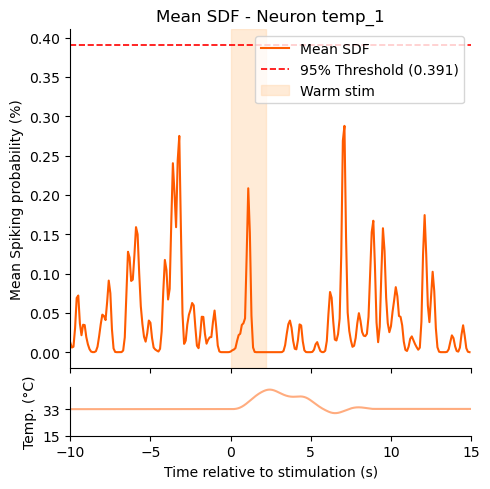

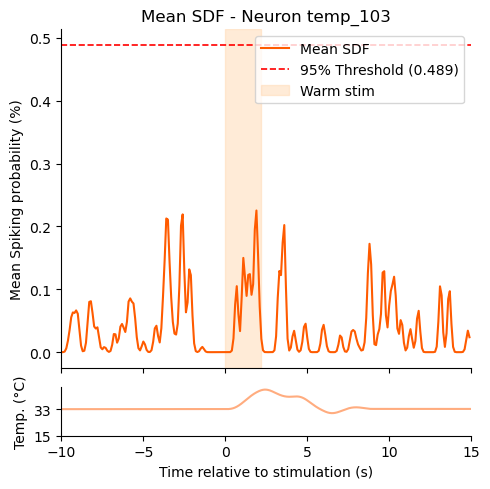

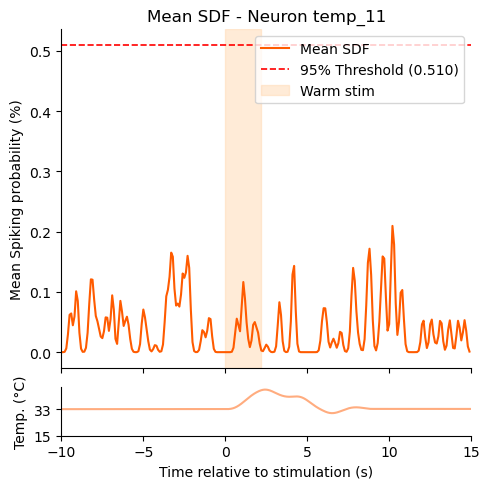

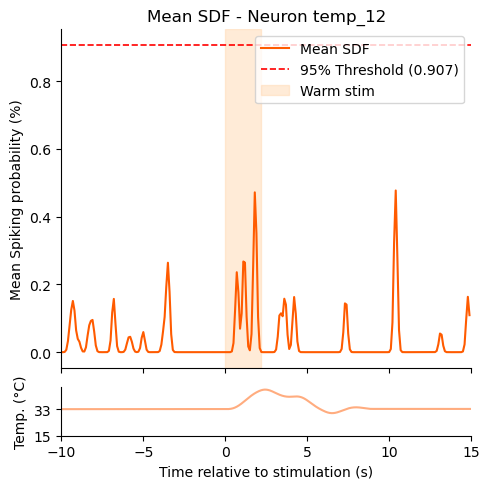

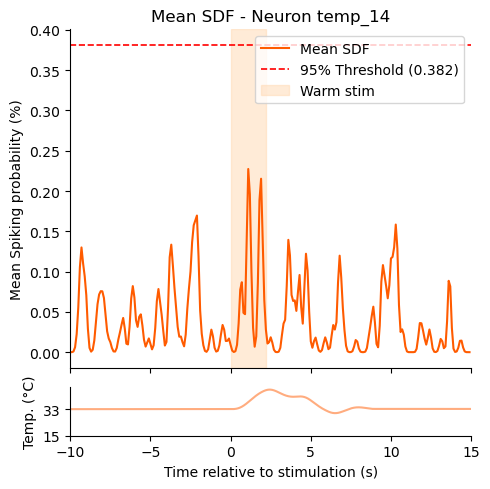

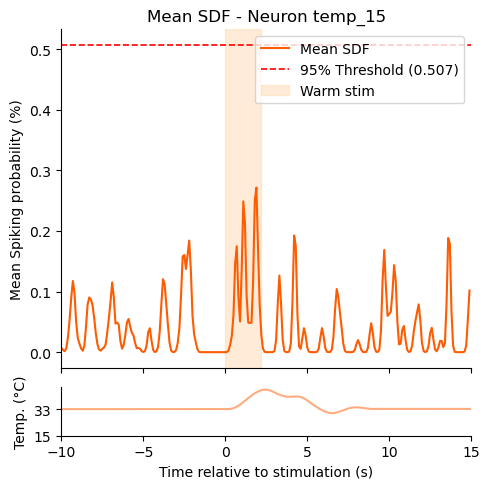

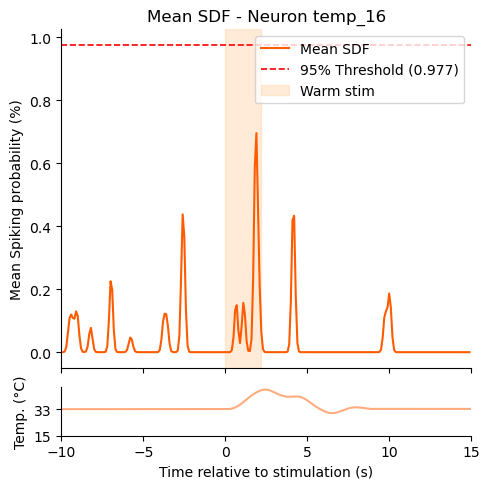

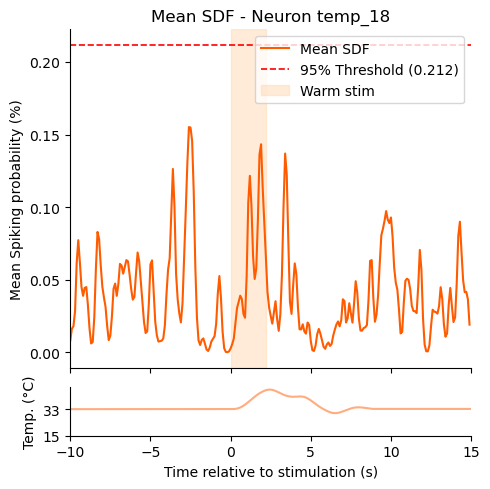

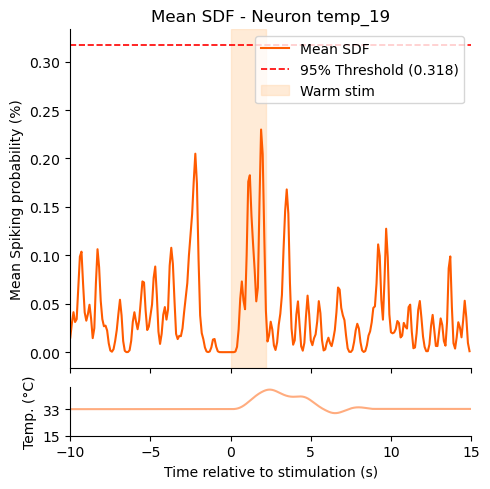

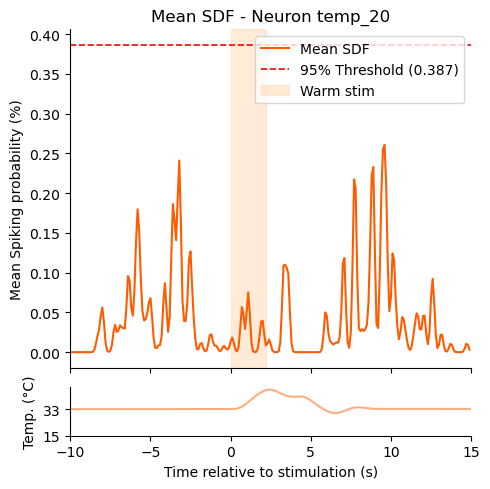

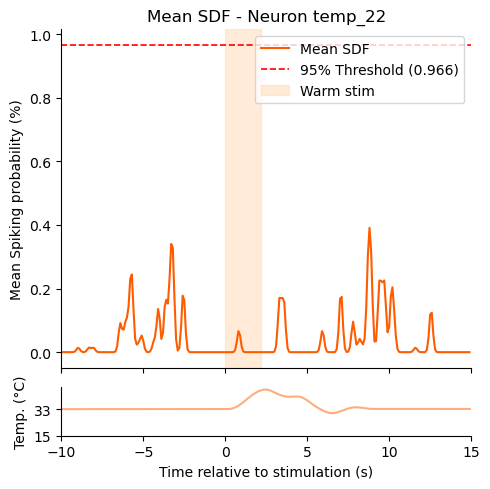

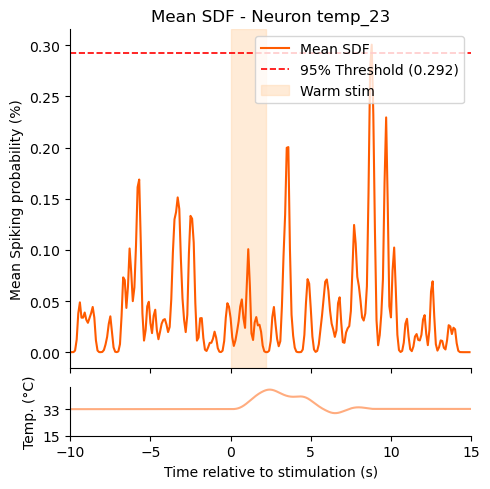

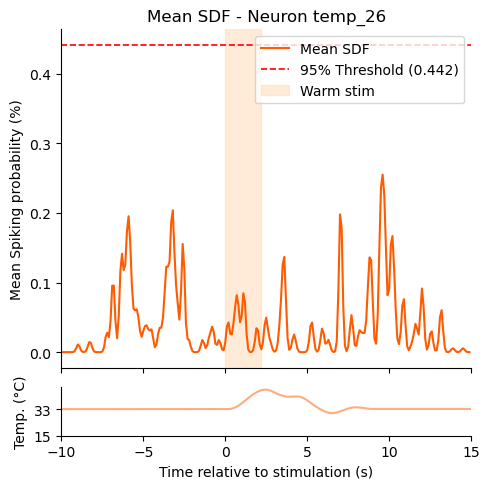

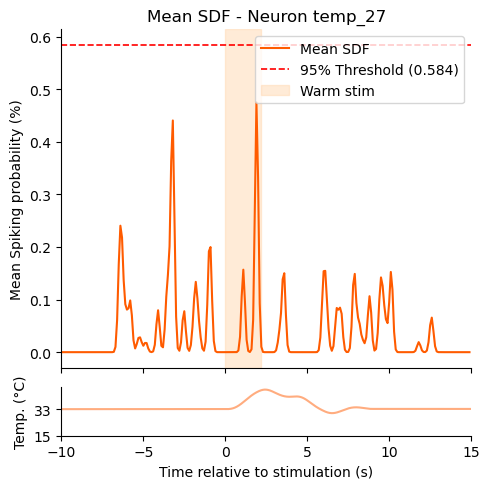

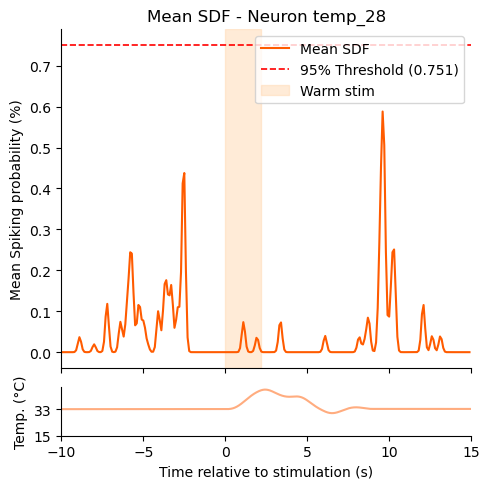

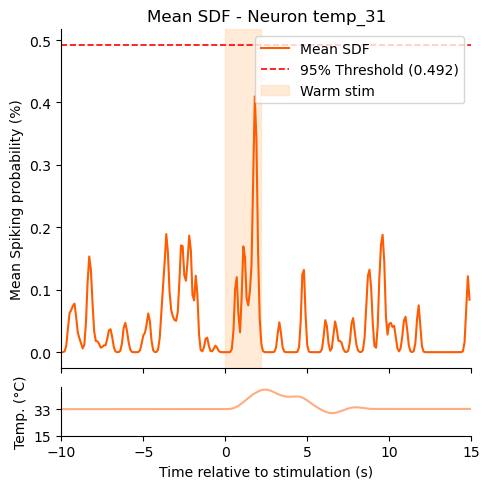

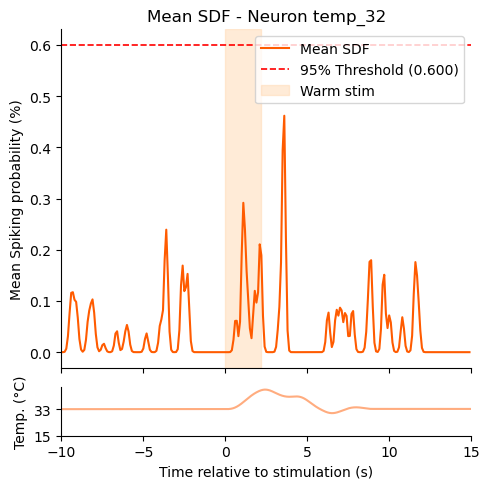

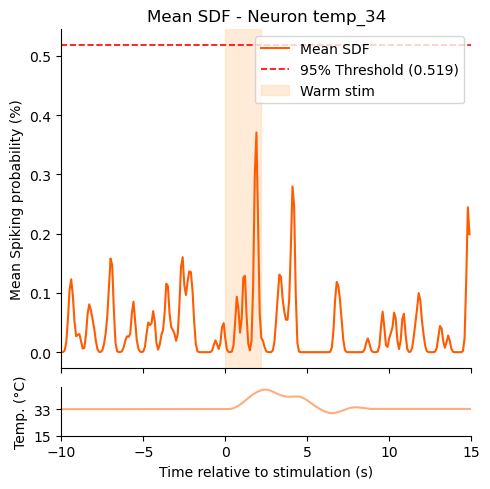

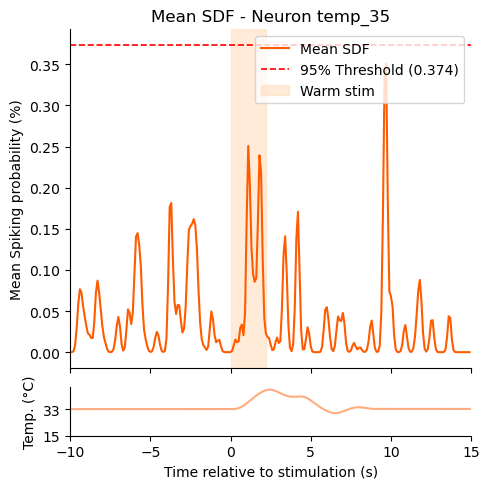

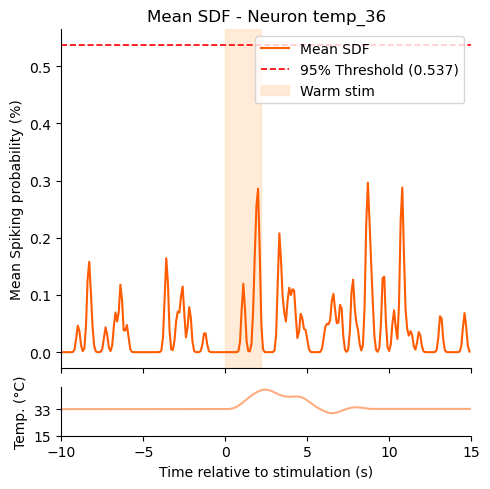

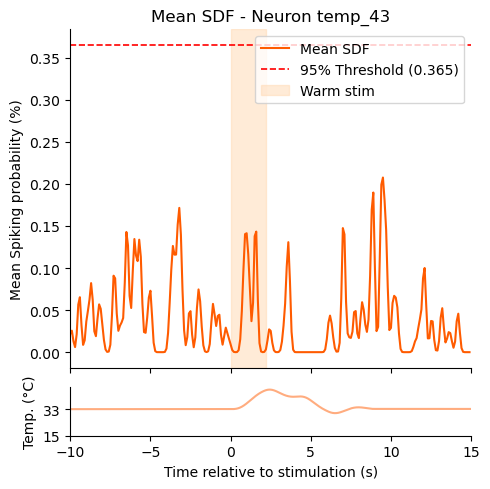

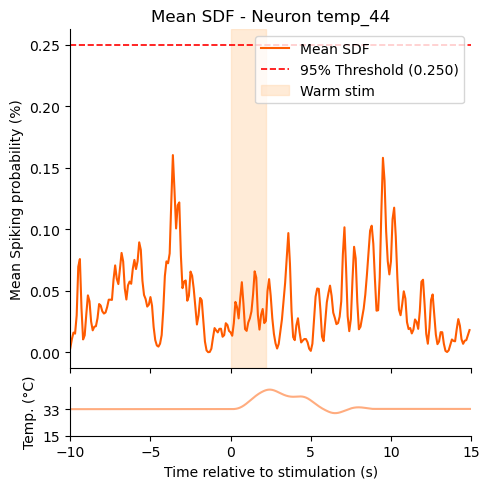

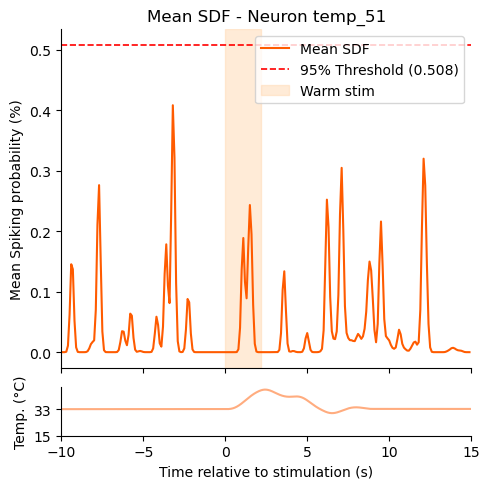

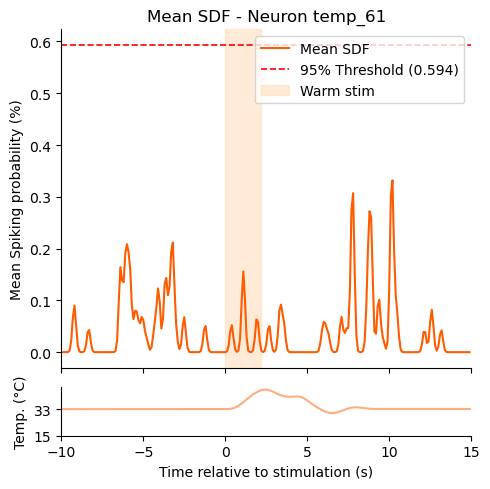

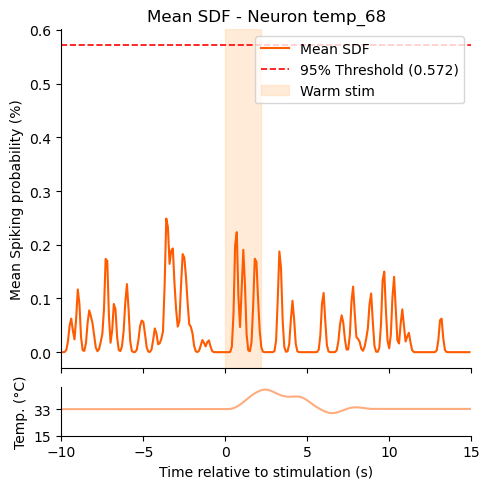

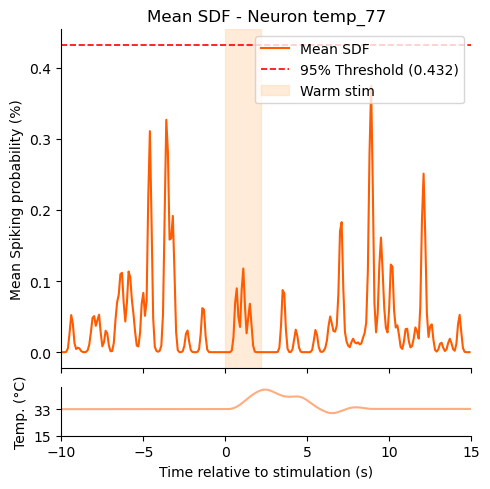

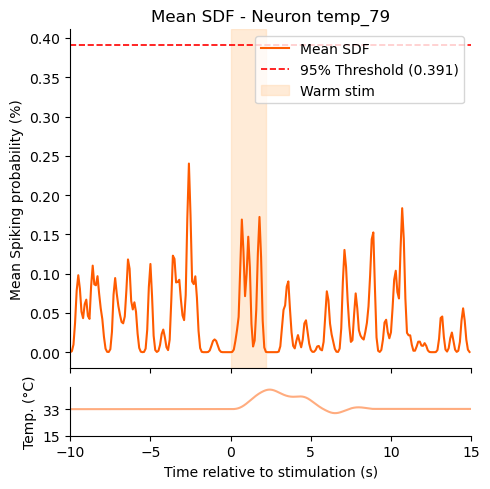

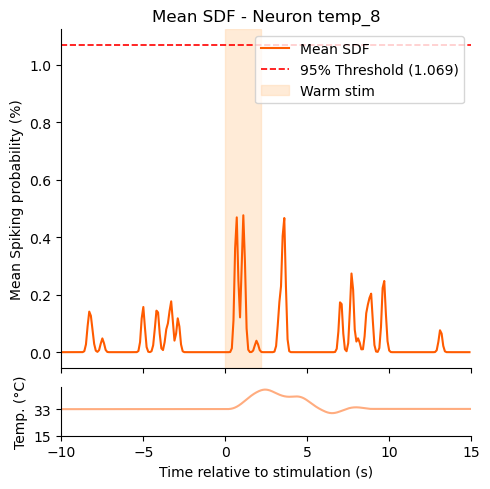

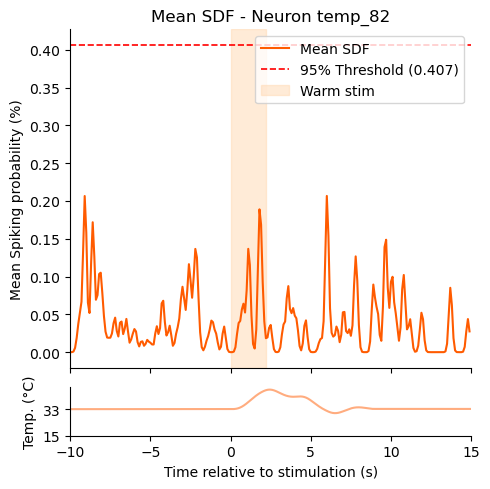

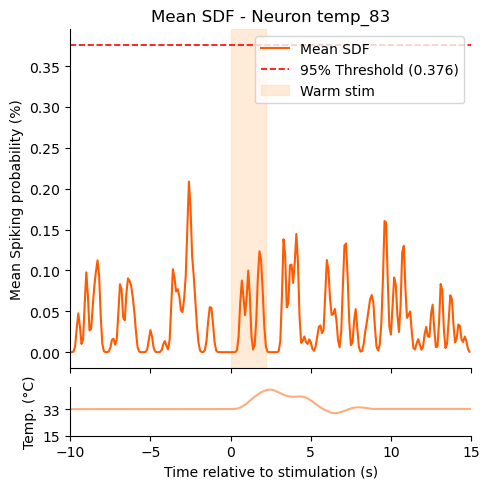

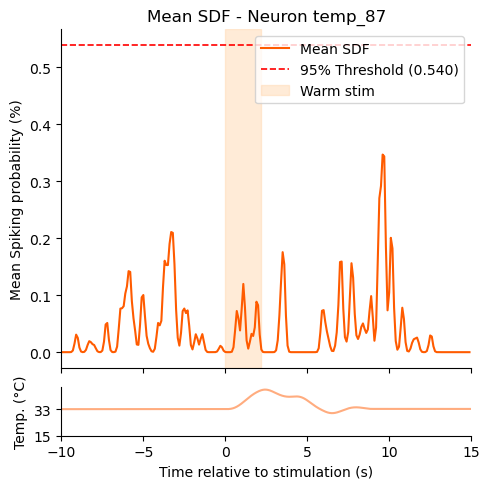

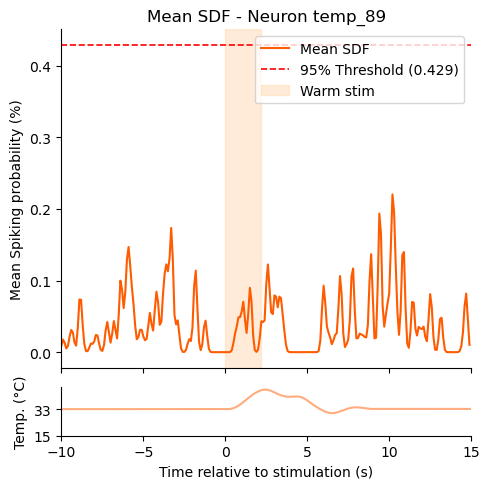

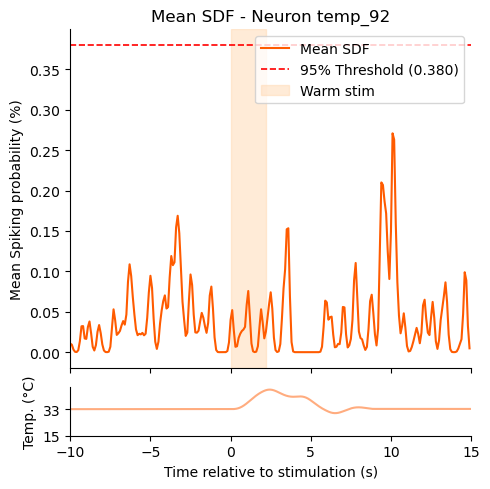

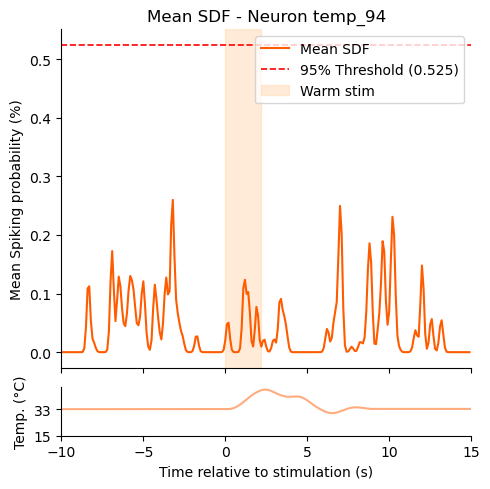

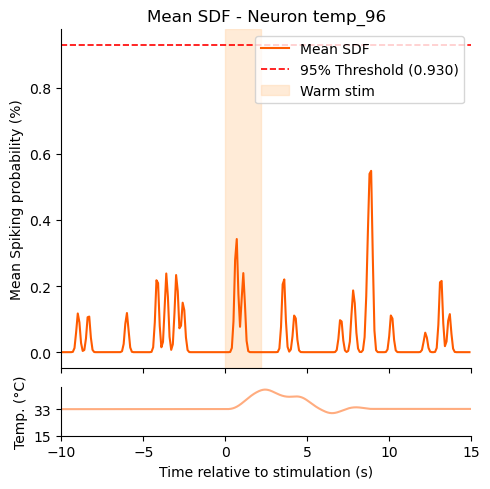

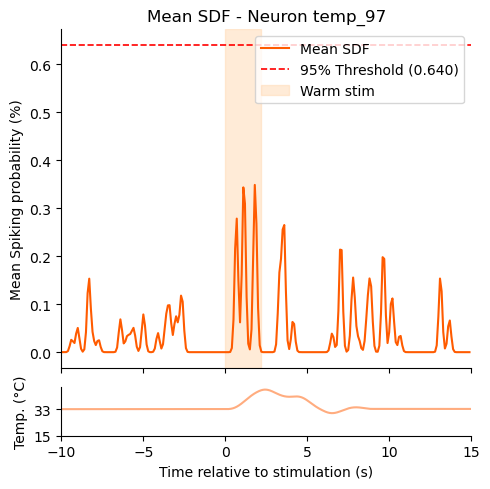

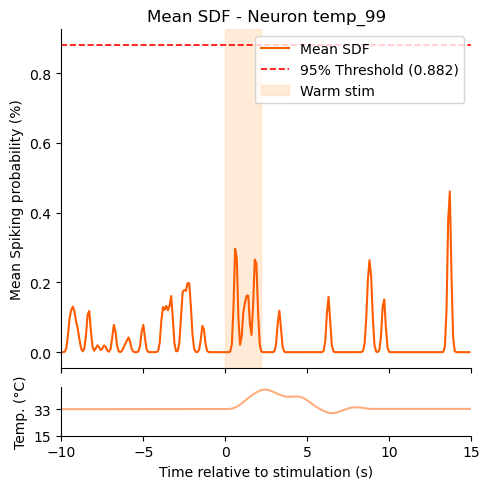

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données depuis le fichier Excel 
sdf_file_xlsx = f'U:\\PhD\\Experimentation\\Electrophysiology\\S1_recordings_Analysis\\spyking_analysis\\sdf_data\\SDF_downs_{sel_folder}_{sel_rec}.xlsx'
df_downs_sdf_xlsx = pd.read_excel(sdf_file_xlsx)


# Étape 1 : Filtrer les valeurs sdf des périodes "Baseline" et "Post_stim"
df_control = df_downs_sdf_xlsx[df_downs_sdf_xlsx["period"].isin(["Baseline", "Post_stim"])]

# Étape 2 : Calculer le 95e percentile des valeurs sdf pour chaque neurone en excluant les valeurs égales à 0
neuron_thresholds = (
    df_control[df_control["sdf"] > 0]
    .groupby("neuron_id")["sdf"]
    .quantile(0.95)
    .to_dict()
)

# Étape 3 : Stocker les seuils sous forme de liste (neuron_id, seuil_95)
threshold_list = [(neuron_id, threshold) for neuron_id, threshold in neuron_thresholds.items()]

# Afficher la liste des seuils
print(threshold_list)

# Identifier tous les neurones présents dans les données
neuron_ids = df_downs_sdf_xlsx['neuron_id'].unique()

# Boucle sur chaque neurone
for neuron_id_to_plot in neuron_ids:
    # Filtrer les données pour le neurone actuel
    df_neuron = df_downs_sdf_xlsx[df_downs_sdf_xlsx['neuron_id'] == neuron_id_to_plot]

    # Calculer la moyenne de la SDF pour tous les trials
    mean_sdf = df_neuron.groupby('stim_time')['sdf'].mean()

    # **Tracer la SDF moyenne avec un subplot pour la température**
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

    # **Premier subplot : SDF moyenne**
    ax1.plot(mean_sdf, color='#ff5b00', label='Mean SDF', linewidth=1.5)
    ax1.set_ylabel("Mean Spiking probability (%)")
    ax1.set_title(f"Mean SDF - Neuron {neuron_id_to_plot}")
    ax1.set_xlim(-10, 15)

    # **Ajouter la ligne du seuil 95e percentile**
    threshold = neuron_thresholds.get(neuron_id_to_plot, None)  # Récupérer le seuil pour ce neurone
    if threshold is not None:
        ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=1.2, label=f'95% Threshold ({threshold:.3f})')

    # Marqueurs des phases du stimulus
    ax1.axvspan(0, 2.2, color='#ffd8b1', label='Warm stim', alpha=0.5, zorder=0)

    ax1.legend(loc="upper right")

    # **Deuxième subplot : Température**
    ax2.plot(t_plot, temp_plot_smoothed, color='#ff5b00', alpha=0.5)
    ax2.set_ylabel("Temp. (°C)")
    ax2.set_xlabel("Time relative to stimulation (s)")
    ax2.set_yticks([15, 33])
    ax2.set_yticklabels(['15', '33'])
    ax2.set_xlim(-10, 15)


    # Cache les bords inutiles
    ax1.spines[['top']].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines[['top']].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Affichage du graphique pour ce neurone
    plt.tight_layout()
    plt.show()


# Codification de la réponse

In [ ]:
# Initialiser une liste pour stocker les résultats
response_list = []

# Boucle sur chaque neurone
for neuron_id in neuron_ids:
    # Filtrer les données pour le neurone actuel
    df_neuron = df_downs_sdf_xlsx[df_downs_sdf_xlsx['neuron_id'] == neuron_id]

    # Calculer la moyenne de la SDF pour tous les trials
    mean_sdf = df_neuron.groupby('stim_time')['sdf'].mean()

    # Extraire la valeur maximale de sdf_mean pendant la période "Stim"
    max_sdf_mean_stim = mean_sdf.loc[df_neuron[df_neuron["period"] == "Stim"]["stim_time"]].max()

    # Récupérer le seuil du neurone
    threshold = neuron_thresholds.get(neuron_id, None)

    # Vérifier si max_sdf_mean_stim dépasse le seuil
    response = 1 if threshold is not None and max_sdf_mean_stim > threshold else 0

    # Ajouter les résultats à la liste
    response_list.append([neuron_id, threshold, max_sdf_mean_stim, response])

# Convertir la liste en DataFrame
df_response = pd.DataFrame(response_list, columns=['neuron_id', 'threshold', 'max_sdf_mean_stim', 'response'])

# Afficher le tableau final
print(df_response)


   neuron_id  threshold  max_sdf_mean_stim  response
0    temp_13   0.327657           0.118132         0
1    temp_14   0.521833           0.143694         0
2    temp_23   0.469074           0.054825         0
3    temp_25   0.452829           0.211003         0
4    temp_26   0.910661           0.246112         0
5    temp_30   0.361808           0.166012         0
6    temp_34   0.483317           0.124807         0
7     temp_4   0.461974           0.312852         0
8    temp_40   0.760591           0.428193         0
9    temp_41   0.433387           0.350267         0
10   temp_46   0.848881           0.058261         0
11   temp_47   0.457217           0.352413         0
12   temp_51   1.095990           0.350824         0
13   temp_56   0.455644           0.165688         0
14   temp_61   0.413174           0.166541         0
15    temp_9   1.700467           0.475206         0


In [ ]:
import os

# Chemin du dossier à créer
response_folder_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/reponse_data'

# Vérifier si le dossier existe déjà
if not os.path.exists(response_folder_path):
    os.makedirs(response_folder_path)
    print(f"Dossier créé : {response_folder_path}")
else:
    print(f"Le dossier existe déjà : {response_folder_path}")


Le dossier existe déjà : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/reponse_data


avec code reponse neurone threshold

In [ ]:
import pandas as pd

# Initialiser une liste pour stocker les résultats
response_list = []

# Boucle sur chaque neurone
for neuron_id in neuron_ids:
    # Filtrer les données pour le neurone actuel
    df_neuron = df_downs_sdf_xlsx[df_downs_sdf_xlsx['neuron_id'] == neuron_id]

    # Calculer la moyenne de la SDF pour tous les trials
    mean_sdf = df_neuron.groupby('stim_time')['sdf'].mean()

    # Extraire la valeur maximale de sdf_mean pendant la période "Stim"
    max_sdf_mean_stim = mean_sdf.loc[df_neuron[df_neuron["period"] == "Stim"]["stim_time"]].max()

    # Récupérer le seuil du neurone
    threshold = neuron_thresholds.get(neuron_id, None)

    # Vérifier si max_sdf_mean_stim dépasse le seuil
    response = 1 if threshold is not None and max_sdf_mean_stim > threshold else 0

    # Ajouter les résultats à la liste, avec les nouvelles colonnes animal et rec
    response_list.append([sel_folder, sel_rec, neuron_id, threshold, max_sdf_mean_stim, response])

# Convertir la liste en DataFrame
df_neuron_response = pd.DataFrame(response_list, columns=['animal', 'rec', 'neuron_id', 'threshold', 'max_sdf_mean_stim', 'response'])

# Charger le fichier des informations supplémentaires
info_file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/animlal_info_for_ephy_df.xlsx"
df_info_rec = pd.read_excel(info_file_path)

# Trouver la ligne correspondant à sel_folder et sel_rec
selected_row = df_info_rec[(df_info_rec["Directory"] == sel_folder) & (df_info_rec["File_name"] == sel_rec)]

# Si une ligne correspond, extraire les informations
if not selected_row.empty:
    cdt = selected_row["cdt"].values[0]
    side = selected_row["side"].values[0]
    genotype = selected_row["genotype"].values[0]
    age = selected_row["age"].values[0]
    sex = selected_row["sex"].values[0]
    depth = selected_row["depth"].values[0]
    aCSF = selected_row["aCSF"].values[0]
    TTLtemp = selected_row["TTLtemp"].values[0]
    directory = selected_row["Directory"].values[0]
    file_name = selected_row["File_name"].values[0]
else:
    print(f"Aucune correspondance trouvée pour {sel_folder} et {sel_rec}.")
    cdt = side = genotype = age = sex = depth = aCSF = TTLtemp = directory = file_name = None

# Ajouter les informations supplémentaires dans le DataFrame
df_neuron_response['cdt'] = cdt
df_neuron_response['side'] = side
df_neuron_response['genotype'] = genotype
df_neuron_response['age'] = age
df_neuron_response['sex'] = sex
df_neuron_response['depth'] = depth
df_neuron_response['aCSF'] = aCSF
df_neuron_response['TTLtemp'] = TTLtemp
df_neuron_response['directory'] = directory
df_neuron_response['file_name'] = file_name


# Liste des colonnes dans l'ordre souhaité
ordered_columns = [
    "directory", "file_name", "cdt", "side", "genotype", "age", "sex", "depth", "aCSF", "TTLtemp",
    "neuron_id", 'neuron_id', 'threshold', 'max_sdf_mean_stim', 'response'
]

# Réorganiser les colonnes
df_neuron_response = df_neuron_response[ordered_columns]

# Sauvegarder le DataFrame enrichi dans un fichier Excel
file_name = f"Neuron_resp_{sel_folder}_{sel_rec}.xlsx"
full_file_path = response_folder_path + "\\" + file_name 

df_neuron_response.to_excel(full_file_path, index=False)

print(f"Downsampling terminé et sauvegardé avec succès dans {full_file_path}")

Downsampling terminé et sauvegardé avec succès dans U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/reponse_data\Neuron_resp_2024.05.22_allego_9__uid0522-17-08-15.xlsx


# plot sdf_mean seul

In [ ]:
# # Charger les données depuis le fichier Excel
# sdf_file_xlsx = f'U:\\PhD\\Experimentation\\Electrophysiology\\S1_recordings_Analysis\\spyking_analysis\\sdf_data\\SDF_downs_{sel_folder}_{sel_rec}.xlsx'
# df_downs_sdf_xlsx = pd.read_excel(sdf_file_xlsx)

# # Identifier tous les neurones présents dans les données
# neuron_ids = df_downs_sdf_xlsx['neuron_id'].unique()

# # Boucle sur chaque neurone
# for neuron_id_to_plot in neuron_ids:
#     # Filtrer les données pour le neurone actuel
#     df_neuron = df_downs_sdf_xlsx[df_downs_sdf_xlsx['neuron_id'] == neuron_id_to_plot]

#     # Calculer la moyenne de la SDF pour tous les trials
#     mean_sdf = df_neuron.groupby('stim_time')['sdf'].mean()

#     # **Tracer la SDF moyenne avec un subplot pour la température**
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

#     # **Premier subplot : SDF moyenne**
#     ax1.plot(mean_sdf, color='#2a7e19', label='Mean SDF', linewidth=1.5)
#     ax1.set_ylabel("Mean Spiking probability (%)")
#     ax1.set_title(f"Mean SDF - Neuron {neuron_id_to_plot}")
#     ax1.set_xlim(-10, 15)

#     # Marqueurs des phases du stimulus
#     ax1.axvspan(0, 2, color='#d9fdd2', label='Tactile stim', zorder=0)

#     ax1.legend(loc="upper right")

#       # **Deuxième subplot : Température**
#     ax2.plot(t_plot, temp_plot_smoothed, color='#2a7e19', alpha=0.5)
#     ax2.set_ylabel("Stim")
#     ax2.set_xlabel('Time relative to stim (s)')
#     ax2.set_yticks([25, 27])
#     ax2.set_yticklabels(['Off', 'On'])
#     ax2.set_ylim (25, 27)
#     ax2.set_xlim (-10, 15)


#     # Cache les bords inutiles
#     ax1.spines[['top']].set_visible(False)
#     ax1.spines['right'].set_visible(False)
#     ax2.spines[['top']].set_visible(False)
#     ax2.spines['right'].set_visible(False)

#     # Affichage du graphique pour ce neurone
#     plt.tight_layout()
#     plt.show()


# -> Calcul du sdf_mean pour les 3 period de chaq neurone

C:\Users\zayan\AppData\Local\Temp\ipykernel_46660\925884967.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_downs_sdf_xlsx.groupby(["neuron_id", "trial_id", "period"])["sdf"].agg(["mean", sem]).reset_index()


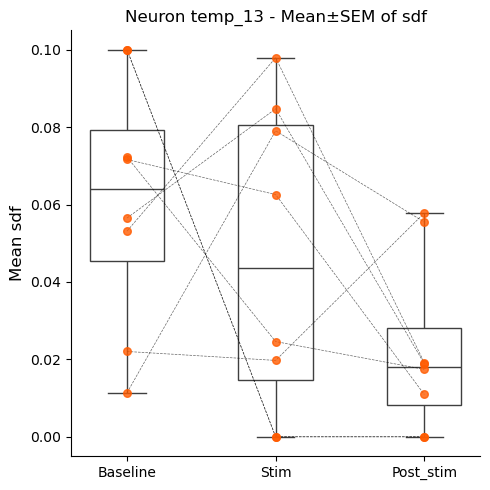

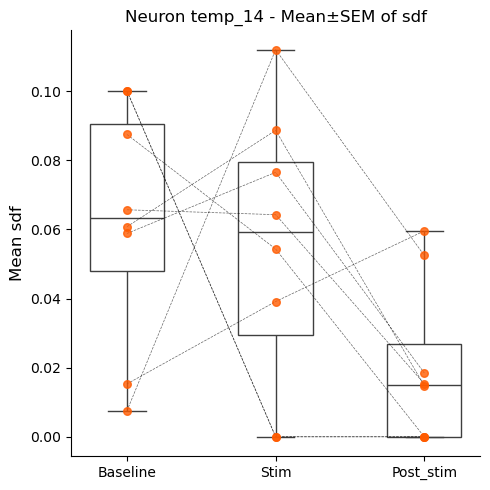

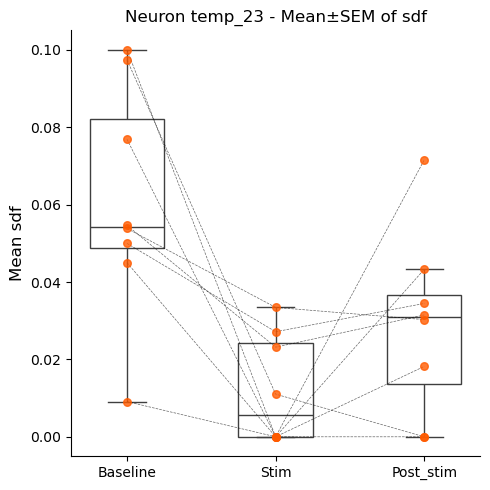

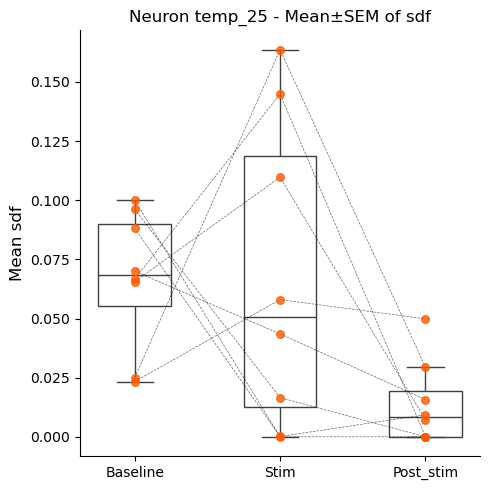

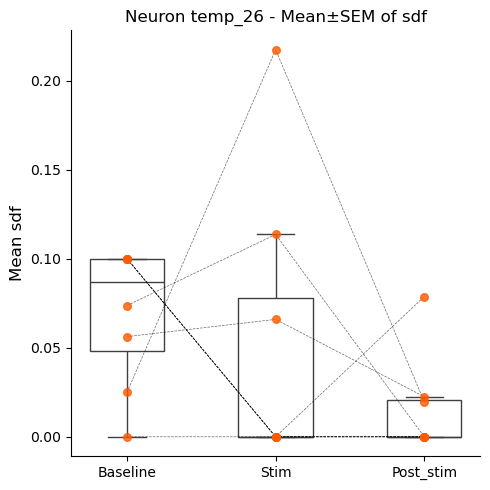

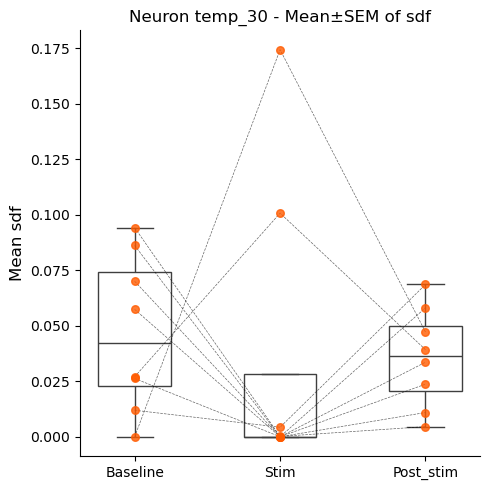

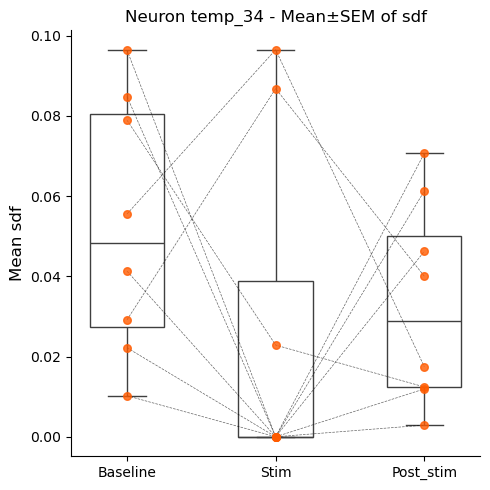

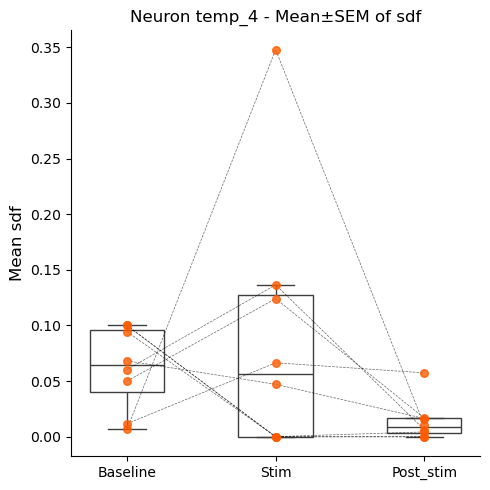

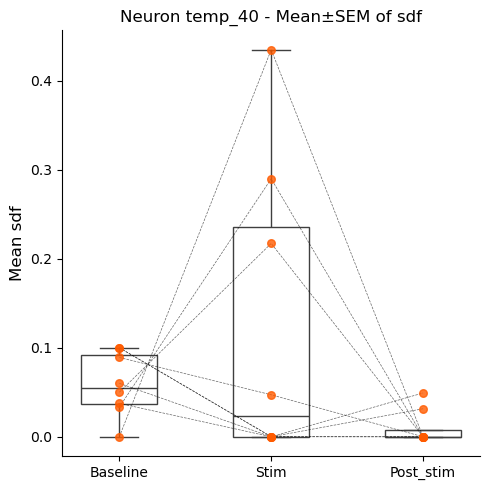

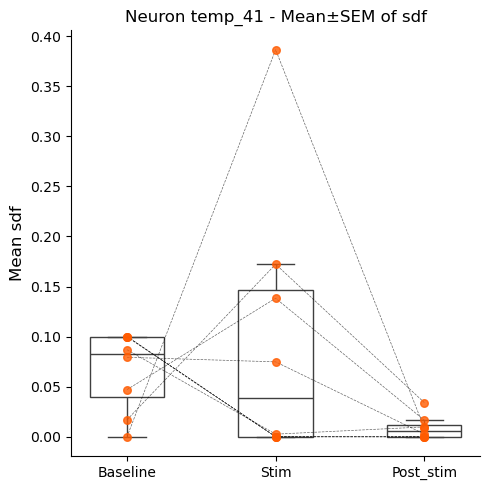

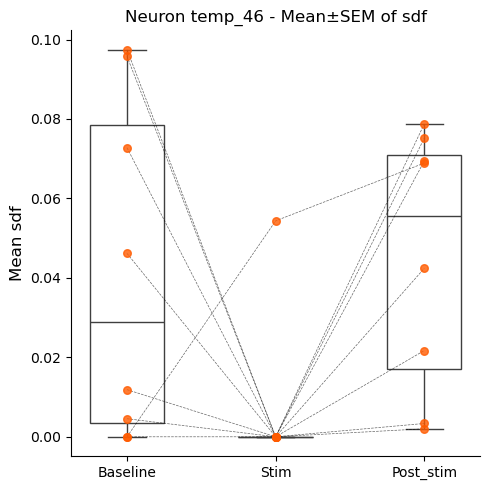

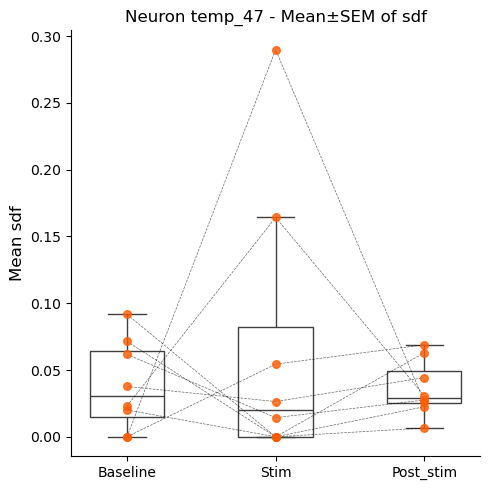

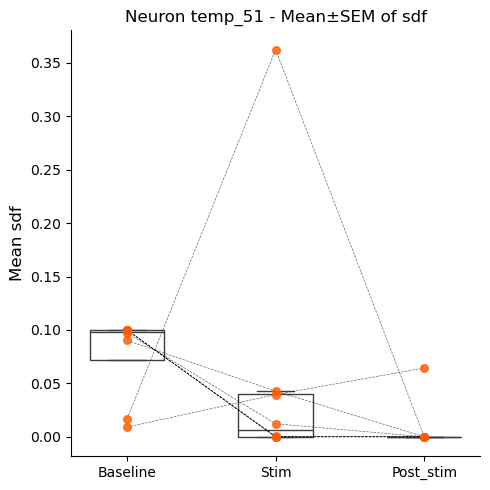

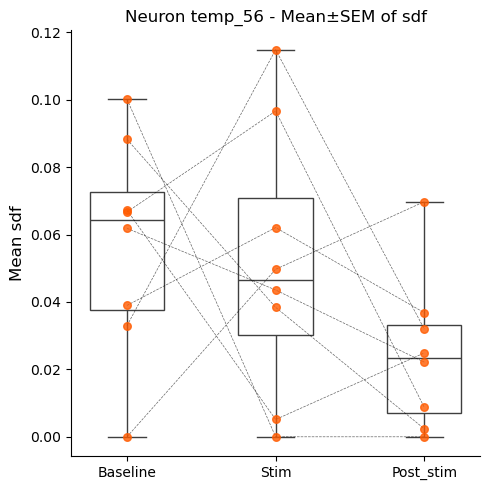

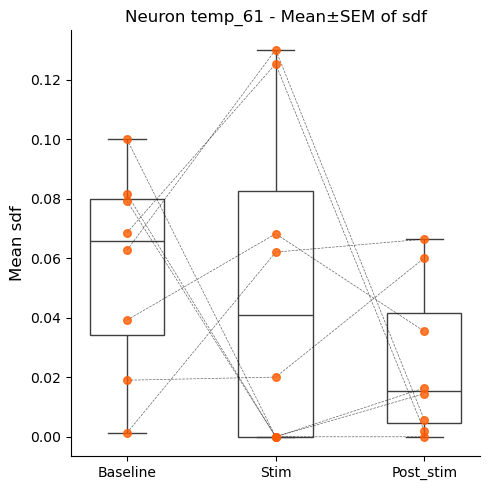

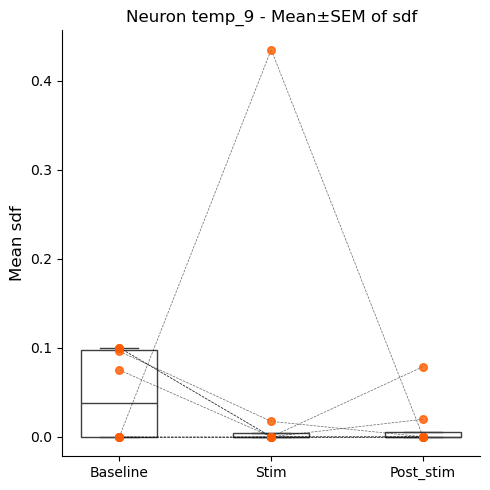

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem
from pandas.api.types import CategoricalDtype

# Charger le fichier Excel
sdf_file_xlsx = f'U:\\PhD\\Experimentation\\Electrophysiology\\S1_recordings_Analysis\\spyking_analysis\\sdf_data\\SDF_downs_{sel_folder}_{sel_rec}.xlsx'
df_downs_sdf_xlsx = pd.read_excel(sdf_file_xlsx)

# Définir l'ordre des périodes
period_order = ["Baseline", "Stim", "Post_stim"]
df_downs_sdf_xlsx["period"] = df_downs_sdf_xlsx["period"].astype(CategoricalDtype(categories=period_order, ordered=True))

# Calculer la moyenne et le SEM pour chaque neuron_id, trial_id et période
df_summary = df_downs_sdf_xlsx.groupby(["neuron_id", "trial_id", "period"])["sdf"].agg(["mean", sem]).reset_index()

# Renommer les colonnes
df_summary.rename(columns={"mean": "sdf_mean", "sem": "sdf_sem"}, inplace=True)

# Liste des neurones uniques
neurons = df_summary["neuron_id"].unique()

# Tracer un graphique pour chaque neurone
for neuron in neurons:
    plt.figure(figsize=(5, 5))
    
    # Filtrer les données pour ce neurone
    df_neuron = df_summary[df_summary["neuron_id"] == neuron]
    
    # Boxplot des valeurs sdf_mean par période (couleur gris clair)
    sns.boxplot(x="period", y="sdf_mean", data=df_neuron, showfliers=False, 
                boxprops={'facecolor': 'white'}, width=0.5, zorder=0)
    
    # Tracer des lignes reliant les points du même trial_id entre les périodes (couleur cyan)
    for trial_id in df_neuron["trial_id"].unique():
        df_trial = df_neuron[df_neuron["trial_id"] == trial_id]
        plt.plot(df_trial["period"], df_trial["sdf_mean"], linestyle="--", color='k', linewidth=0.5, alpha=0.6, zorder=1)

    # Tracer les points séparément (couleur cyan, avec taille 30)
    plt.scatter(df_neuron["period"], df_neuron["sdf_mean"], color='#ff5b00', s=30, alpha=0.8, zorder=1)

    # Personnalisation du plot
    plt.title(f"Neuron {neuron} - Mean±SEM of sdf")
    plt.xlabel("")
    plt.ylabel("Mean sdf")


    #Ajustement des bordures
    # Enlever les bordures du haut et de droite pour le premier subplot
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    plt.rcParams.update({
        'axes.labelsize': 12,   # Taille des labels des axes
        'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
        'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
        'legend.fontsize': 9   # Taille de la police de la légende
    })

    plt.tight_layout()

    plt.show()


# Export des valeures de mean_sdf

In [ ]:
# import pandas as pd
# from pandas.api.types import CategoricalDtype
# from scipy.stats import sem

# # Définir l'ordre des périodes (assurez-vous que cela correspond à l'ordre réel dans vos données)
# period_order = ["Baseline", "Stim", "Post_stim"]
# df_downs_sdf_xlsx["period"] = df_downs_sdf_xlsx["period"].astype(CategoricalDtype(categories=period_order, ordered=True))

# # Calculer la moyenne et le SEM pour chaque neuron_id, trial_id et période
# df_summary = df_downs_sdf_xlsx.groupby(["neuron_id", "trial_id", "period"])["sdf"].agg(["mean", sem]).reset_index()

# # Renommer les colonnes pour plus de clarté
# df_summary.rename(columns={"mean": "sdf_mean", "sem": "sdf_sem"}, inplace=True)

# # Afficher le tableau final
# print(df_summary)

# # Exporter vers un fichier CSV
# output_file_path = "U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\spyking_analysis\sdf_data\sdf_for_graphpad.xlsx"
# df_summary.to_excel(output_file_path, index=False)

# print(f"Le fichier CSV a été exporté avec succès : {output_file_path}")


# Comparaison stat

### Friedman - dunn test

In [ ]:
# import numpy as np
# import pandas as pd
# import scipy.stats as stats
# import scikit_posthocs as sp

# # Charger le fichier Excel
# sdf_file_xlsx = f'U:\\PhD\\Experimentation\\Electrophysiology\\S1_recordings_Analysis\\spyking_analysis\\sdf_data\\SDF_downs_{sel_folder}_{sel_rec}.xlsx'
# df_downs_sdf_xlsx = pd.read_excel(sdf_file_xlsx)

# # Définir l'ordre des périodes
# period_order = ["Baseline", "Stim", "Post_stim"]
# df_downs_sdf_xlsx["period"] = pd.Categorical(df_downs_sdf_xlsx["period"], categories=period_order, ordered=True)

# # Calculer la moyenne pour chaque neuron_id, trial_id et période
# df_summary = df_downs_sdf_xlsx.groupby(["neuron_id", "trial_id", "period"], observed=False)["sdf"].mean().reset_index()

# # Renommer la colonne de la moyenne
# df_summary.rename(columns={"sdf": "sdf_mean"}, inplace=True)

# # Liste des neurones uniques
# neurons = df_summary["neuron_id"].unique()

# # Liste pour stocker les résultats de Friedman et Dunn
# friedman_results = []
# dunn_results = []

# # Effectuer le test de Friedman et de Dunn pour chaque neurone
# for neuron in neurons:
    
#     # Filtrer les données pour ce neurone
#     df_neuron = df_summary[df_summary["neuron_id"] == neuron]

#     # Reformater les données pour Friedman (valeurs appariées par trial)
#     df_friedman = df_neuron.pivot(index="trial_id", columns="period", values="sdf_mean")

#     # Effectuer le test de Friedman (test pour mesures répétées)
#     stat, p_value_friedman = stats.friedmanchisquare(df_friedman["Baseline"], 
#                                                      df_friedman["Stim"], 
#                                                      df_friedman["Post_stim"])

#     # Déterminer la significativité
#     if p_value_friedman < 0.001:
#         significance_friedman = "***"
#     elif p_value_friedman < 0.01:
#         significance_friedman = "**"
#     elif p_value_friedman < 0.05:
#         significance_friedman = "*"
#     else:
#         significance_friedman = "n.s"
  
#     # Stocker les résultats du test de Friedman
#     friedman_results.append([neuron, p_value_friedman, significance_friedman])

#     # Si Friedman est significatif, effectuer le test post-hoc de Dunn
#     if p_value_friedman < 0.05:
#         posthoc_results = sp.posthoc_dunn(df_neuron, val_col="sdf_mean", group_col="period", p_adjust="bonferroni")

#         # Comparaison Baseline vs Stim
#         p_value_baseline_stim = posthoc_results.loc["Baseline", "Stim"]
#         significance_baseline_stim = "***" if p_value_baseline_stim < 0.001 else "**" if p_value_baseline_stim < 0.01 else "*" if p_value_baseline_stim < 0.05 else "n.s"
#         comparison_baseline_stim = "Baseline > Stim" if df_friedman["Baseline"].mean() > df_friedman["Stim"].mean() else "Stim > Baseline" if significance_baseline_stim != "n.s" else "n.s"

#         # Comparaison Baseline vs Post_stim
#         p_value_baseline_poststim = posthoc_results.loc["Baseline", "Post_stim"]
#         significance_baseline_poststim = "***" if p_value_baseline_poststim < 0.001 else "**" if p_value_baseline_poststim < 0.01 else "*" if p_value_baseline_poststim < 0.05 else "n.s"
#         comparison_baseline_poststim = "Baseline > Post_stim" if df_friedman["Baseline"].mean() > df_friedman["Post_stim"].mean() else "Post_stim > Baseline" if significance_baseline_poststim != "n.s" else "n.s"

#         # Comparaison Stim vs Post_stim
#         p_value_stim_poststim = posthoc_results.loc["Stim", "Post_stim"]
#         significance_stim_poststim = "***" if p_value_stim_poststim < 0.001 else "**" if p_value_stim_poststim < 0.01 else "*" if p_value_stim_poststim < 0.05 else "n.s"
#         comparison_stim_poststim = "Stim > Post_stim" if df_friedman["Stim"].mean() > df_friedman["Post_stim"].mean() else "Post_stim > Stim" if significance_stim_poststim != "n.s" else "n.s"

#         # Stocker les résultats du test de Dunn
#         dunn_results.append([neuron, "Baseline vs Stim", p_value_baseline_stim, significance_baseline_stim, comparison_baseline_stim])
#         dunn_results.append([neuron, "Baseline vs Post_stim", p_value_baseline_poststim, significance_baseline_poststim, comparison_baseline_poststim])
#         dunn_results.append([neuron, "Stim vs Post_stim", p_value_stim_poststim, significance_stim_poststim, comparison_stim_poststim])

# # Convertir les résultats en DataFrames
# df_friedman_results = pd.DataFrame(friedman_results, columns=["Neuron", "p-value (Friedman)", "Significance (Friedman)"])
# df_dunn_results = pd.DataFrame(dunn_results, columns=["Neuron", "Comparison", "p-value (Dunn)", "Significance (Dunn)", "Larger Period"])

# # Afficher les résultats
# print("Friedman Results:")
# print(df_friedman_results)

# print("\nDunn Post-Hoc Results:")
# print(df_dunn_results)


### Anova One-way RM - Tukey posthoc

In [ ]:
import os

# Chemin du dossier à créer
Anova_response_folder_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/Anova_reponse_data'

# Vérifier si le dossier existe déjà
if not os.path.exists(Anova_response_folder_path):
    os.makedirs(Anova_response_folder_path)
    print(f"Dossier créé : {Anova_response_folder_path}")
else:
    print(f"Le dossier existe déjà : {Anova_response_folder_path}")


Le dossier existe déjà : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/Anova_reponse_data


avec code reponse neurone

In [ ]:
import numpy as np 
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Charger le fichier Excel
sdf_file_xlsx = f'U:\\PhD\\Experimentation\\Electrophysiology\\S1_recordings_Analysis\\spyking_analysis\\sdf_data\\SDF_downs_{sel_folder}_{sel_rec}.xlsx'
df_downs_sdf_xlsx = pd.read_excel(sdf_file_xlsx)

# Définir l'ordre des périodes
period_order = ["Baseline", "Stim", "Post_stim"]
df_downs_sdf_xlsx["period"] = pd.Categorical(df_downs_sdf_xlsx["period"], categories=period_order, ordered=True)

# Calculer la moyenne pour chaque neuron_id, trial_id et période
df_summary = df_downs_sdf_xlsx.groupby(["neuron_id", "trial_id", "period"], observed=False)["sdf"].mean().reset_index()
df_summary.rename(columns={"sdf": "sdf_mean"}, inplace=True)

# Liste des neurones uniques
neurons = df_summary["neuron_id"].unique()

# Stocker les résultats
anova_results = []
tukey_results = []
response_results = []  # Liste pour stocker si le neurone a répondu (1) ou non (0)

# Boucle sur chaque neurone pour l'ANOVA à mesures répétées
for neuron in neurons:
    
    # Filtrer les données pour ce neurone
    df_neuron = df_summary[df_summary["neuron_id"] == neuron]

    # Vérifier si chaque période a au moins 2 essais pour que l'ANOVA soit valide
    if df_neuron["trial_id"].nunique() < 2:
        continue  # Passer ce neurone s'il a trop peu d'essais

    # ANOVA à mesures répétées
    try:
        anova_model = AnovaRM(data=df_neuron, depvar="sdf_mean", subject="trial_id", within=["period"]).fit()
        p_value_anova = anova_model.anova_table["Pr > F"].iloc[0]

        # Déterminer la significativité
        significance_anova = "***" if p_value_anova < 0.001 else "**" if p_value_anova < 0.01 else "*" if p_value_anova < 0.05 else "n.s"
        anova_results.append([neuron, p_value_anova, significance_anova])

        # Ajouter une ligne pour la réponse du neurone si l'ANOVA est non significative
        if significance_anova == "n.s":
            response_results.append([neuron, 0])  # Le neurone n'a pas répondu si l'ANOVA est non significative

        # Test post-hoc de Tukey **seulement si l'ANOVA est significative**
        if p_value_anova < 0.05:
            tukey = pairwise_tukeyhsd(df_neuron["sdf_mean"], df_neuron["period"], alpha=0.05)

            for res in tukey.summary().data[1:]:
                try:
                    group1, group2, mean_diff, p_value, conf_low, conf_high, reject = res
                    significance_tukey = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s"

                    # Vérifier les moyennes réelles des groupes dans df_neuron
                    mean_group1 = df_neuron[df_neuron["period"] == group1]["sdf_mean"].mean()
                    mean_group2 = df_neuron[df_neuron["period"] == group2]["sdf_mean"].mean()

                    # Stocker les résultats Tukey
                    tukey_results.append([neuron, f"{group1} vs {group2}", p_value, significance_tukey])

                    # Ne considérer la réponse neuronale que pour la comparaison "Baseline vs Stim"
                    if group1 == "Baseline" and group2 == "Stim":
                        # Si la comparaison est significative et Stim > Baseline, on marque la réponse à 1
                        if significance_tukey != "n.s" and mean_group2 > mean_group1:
                            response_results.append([neuron, 1])  # Le neurone a répondu
                        else:
                            response_results.append([neuron, 0])  # Le neurone n'a pas répondu
                
                except ValueError as e:
                    print(f"Erreur d'extraction des résultats Tukey pour le neurone {neuron} : {res}")
                    print(f"Détail de l'erreur : {e}")
                    continue

    except Exception as e:
        print(f"Erreur pour le neurone {neuron} : {e}")
        continue

# Convertir les résultats en DataFrame
df_anova_results = pd.DataFrame(anova_results, columns=["Neuron", "p-value (ANOVA)", "Significance (ANOVA)"])
df_tukey_results = pd.DataFrame(tukey_results, columns=["Neuron", "Comparison", "p-value (Tukey)", "Significance (Tukey)"])

# Ajouter les résultats de réponse à un DataFrame (1 seule ligne par neurone)
df_response_results = pd.DataFrame(response_results, columns=["Neuron", "Response"])
df_response_results = df_response_results.drop_duplicates(subset="Neuron", keep="first")

# Charger le fichier des informations supplémentaires
info_file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/animlal_info_for_ephy_df.xlsx"
df_info_rec = pd.read_excel(info_file_path)

# Trouver la ligne correspondant à sel_folder et sel_rec
selected_row = df_info_rec[(df_info_rec["Directory"] == sel_folder) & (df_info_rec["File_name"] == sel_rec)]

# Si une ligne correspond, extraire les informations
if not selected_row.empty:
    cdt = selected_row["cdt"].values[0]
    side = selected_row["side"].values[0]
    genotype = selected_row["genotype"].values[0]
    age = selected_row["age"].values[0]
    sex = selected_row["sex"].values[0]
    depth = selected_row["depth"].values[0]
    aCSF = selected_row["aCSF"].values[0]
    TTLtemp = selected_row["TTLtemp"].values[0]
    directory = selected_row["Directory"].values[0]
    file_name = selected_row["File_name"].values[0]
else:
    print(f"Aucune correspondance trouvée pour {sel_folder} et {sel_rec}.")
    cdt = side = genotype = age = sex = depth = aCSF = TTLtemp = directory = file_name = None

# Ajouter les informations supplémentaires dans le DataFrame
df_response_results['cdt'] = cdt
df_response_results['side'] = side
df_response_results['genotype'] = genotype
df_response_results['age'] = age
df_response_results['sex'] = sex
df_response_results['depth'] = depth
df_response_results['aCSF'] = aCSF
df_response_results['TTLtemp'] = TTLtemp
df_response_results['directory'] = directory
df_response_results['file_name'] = file_name


# Liste des colonnes dans l'ordre souhaité
ordered_columns = [
    "directory", "file_name", "cdt", "side", "genotype", "age", "sex", "depth", "aCSF", "TTLtemp",
     'Neuron','Response'
]

# Réorganiser les colonnes
df_response_results = df_response_results[ordered_columns]


# Sauvegarder le DataFrame enrichi dans un fichier Excel
file_name = f"Anova_resp_{sel_folder}_{sel_rec}.xlsx"
full_file_path = Anova_response_folder_path + "\\" + file_name  

with pd.ExcelWriter(full_file_path, engine='xlsxwriter') as writer:
    df_anova_results.to_excel(writer, sheet_name="ANOVA Results", index=False)
    df_tukey_results.to_excel(writer, sheet_name="Tukey Results", index=False)
    df_response_results.to_excel(writer, sheet_name="Neuron Response", index=False)

print(f"Downsampling terminé et sauvegardé avec succès dans {full_file_path}")

print(df_response_results) 

Downsampling terminé et sauvegardé avec succès dans U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/Anova_reponse_data\Anova_resp_2024.05.22_allego_9__uid0522-17-08-15.xlsx
     directory                   file_name      cdt   side genotype age sex  \
0   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
1   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
2   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
3   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
4   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
5   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
6   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
7   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
8   2024.05.22  allego_9__uid0522-17-08-15  Thq-hot  Wipsi       WT  P6   F   
9   

#

# --> Raster plot

### For each neurones with 8 aligned stim

### For each neurones along total rec

In [ ]:
# import matplotlib.pyplot as plt

# # Période d'intérêt (exemple : de 0 à 10 secondes)
# start_time = 0  # début de la période
# end_time = 700  # fin de la période

# # Exemple de périodes de stimulation (début et fin de chaque stimulation)
# t_stim_start = [120.406, 186.407, 252.398, 318.399, 384.4, 450.401, 516.402, 582.403]
# t_stim_end = [129.598, 195.599, 261.6, 327.601, 393.602, 459.603, 525.604, 591.605]

# # On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
# valid_keys = [f'temp_{i}' for i in valid_all]

# # Vérification que les clés existent dans dataset['spiketimes']
# valid_keys = [key for key in valid_keys if key in dataset['spiketimes']]

# # Création du plot
# fig, ax = plt.subplots(figsize=(8, 6))

# # Pour chaque neurone valide, on ajoute une ligne pour chaque spike
# for i, key in enumerate(valid_keys):
#     spikes = dataset['spiketimes'][key]  # Spikes pour ce neurone
    
#     # Filtrage des spiketimes dans la période donnée
#     filtered_spikes = [spike for spike in spikes if start_time <= spike <= end_time]
    
#     # Tracer chaque spike comme une barre verticale
#     for spike in filtered_spikes:
#         ax.plot([spike, spike], [i - 0.4, i + 0.4], color='black')  # Chaque spike comme une ligne verticale

# # Ajouter les périodes de stimulation avec des rectangles transparents
# for stim_start, stim_end in zip(t_stim_start, t_stim_end):
#     ax.axvspan(stim_start, stim_end, color='red', alpha=0.2)  # Rectangle transparent (alpha=0.2) pour la période de stimulation

# # Paramétrage de l'axe
# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Neuron Index')
# ax.set_title('Raster Plot of Spikes with Stimulation Periods')

# # Améliorer la lisibilité
# ax.set_yticks(range(len(valid_keys)))
# ax.set_yticklabels(valid_keys)

# plt.tight_layout()
# plt.show()


### Exemple

In [ ]:
# import matplotlib.pyplot as plt

# # Période d'intérêt (exemple : de 0 à 10 secondes)
# start_time = 110  # début de la période
# end_time = 130  # fin de la période

# # On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
# valid_keys = [f'temp_{i}' for i in valid_all]

# # Vérification que les clés existent dans dataset['spiketimes']
# valid_keys = [key for key in valid_keys if key in dataset['spiketimes']]

# # Création du plot
# fig, ax = plt.subplots(figsize=(10, 6))

# # Pour chaque neurone valide, on ajoute une ligne pour chaque spike
# for i, key in enumerate(valid_keys):
#     spikes = dataset['spiketimes'][key]  # Spikes pour ce neurone
    
#     # Filtrage des spiketimes dans la période donnée
#     filtered_spikes = [spike for spike in spikes if start_time <= spike <= end_time]
    
#     # Tracer chaque spike comme une barre verticale
#     for spike in filtered_spikes:
#         ax.plot([spike, spike], [i - 0.4, i + 0.4], color='black')  # Chaque spike comme une ligne verticale

# # Paramétrage de l'axe
# ax.set_xlabel('Time (s)')
# ax.set_ylabel('Neuron Index')
# ax.set_title('Raster Plot of Spikes')

# # Améliorer la lisibilité
# ax.set_yticks(range(len(valid_keys)))
# ax.set_yticklabels(valid_keys)

# plt.tight_layout()
# plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Paramètres
# time_before_stim = 20  # 10 secondes avant le début du stimulus
# time_after_stim = 10   # 10 secondes après le début du stimulus

# # Créer la figure avec un rapport de taille entre les subplots
# fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
#                               gridspec_kw={'height_ratios': [5, 1]})  # Rapport 3:1 entre le raster et la courbe de température

# # Pour chaque stimulus, aligner les spikes sur le début du stimulus
# for i, key in enumerate(valid_keys):
#     spikes = dataset['spiketimes'][key]  # Spikes pour ce neurone

#     # Pour chaque stimulus, ajuster les spiketimes
#     for j in range(len(t_stim_start)):
#         stim_start = t_stim_start[j]
#         stim_end = t_stim_end[j]

#         # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
#         window_start = stim_start - time_before_stim
#         window_end = stim_end + time_after_stim

#         # Sélectionner les spikes dans cette fenêtre
#         selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]
        
#         # Tracer les spikes alignés pour ce stimulus
#         for spike in selected_spikes:
#             ax.plot([spike, spike], [i - 0.4, i + 0.4], color='black')  # Barre verticale pour chaque spike

# # Ajout de la barre verticale à chaque 0 pour le début du stimulus
# for stim_start in t_stim_start:
#     ax.axvline(0, color='red', linestyle='--')  # Ligne rouge verticale pour le début du stimulus

# # Paramétrage du raster plot
# ax.set_ylabel('Neuron Index')
# ax.set_title('Raster Plot Aligned on Stimuli')

# # Assure-toi que stim_start et stim_end sont correctement définis pour chaque stimulus
# for stim_start, stim_end in zip(t_stim_start, t_stim_end):
#     # Appliquer le masque pour sélectionner la plage de température autour du stimulus
#     mask = (t_lfps > stim_start - time_before_stim) & (t_lfps < stim_end + time_after_stim)

#     # Sélectionner les temps et températures correspondants
#     t_plot = t_lfps[mask] - stim_start  # Temps relatif au stimulus
#     temp_plot = therm_stim[mask]  # Température associée

#     # Tracer la courbe de température
#     ax2.plot(t_plot, temp_plot, color='blue', label=f'Stimulus {i + 1}' if i == 0 else "")

# ax2.set_xlabel('Time (s) relative to stimulus')
# ax2.set_ylabel('Temperature (°C)')

# # Améliorer la lisibilité
# ax.set_yticks(range(len(valid_keys)))
# ax.set_yticklabels(valid_keys)

# # Ajouter une légende pour la température
# ax2.legend(loc='upper right')

# # Ajuster la mise en page
# plt.tight_layout()
# plt.show()


# --> plot tracé brut

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Charger les données du fichier brut
# dat_file = dat_file_path  # Chemin vers votre fichier .dat
# data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes avec le type de données adapté

# # Charger le mapping des canaux
# channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)  # Reshape en shanks (ex: 8 canaux par shank)
# n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
# n_channels = n_shanks * channels_per_shank  # Calculer le nombre total de canaux

# # Vérification du nombre de canaux
# assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# # Paramètres
# sampling_rate = 30000  # Fréquence d'échantillonnage (exemple: 30 kHz)

# # Reshape les données en fonction des canaux
# data_reshaped = data.reshape((-1, n_channels))  # Assure-toi que le fichier contient bien le nombre attendu de canaux

# # Réorganiser les canaux selon le mapping par shank
# mapped_indices = channel_map.flatten()  # Applatir le mapping pour obtenir l'ordre final
# data_mapped = data_reshaped[:, mapped_indices]  # Réorganiser les colonnes selon cet ordre

# # Spécifier une plage de temps à afficher (en secondes)
# start_time = 110  # Début en secondes
# end_time = 140   # Fin en secondes

# # Calculer les indices correspondants à la plage de temps
# start_sample = int(start_time * sampling_rate)
# end_sample = int(end_time * sampling_rate)

# # Extraire les données pour cette plage de temps
# data_to_plot = data_mapped[start_sample:end_sample, :]
# time = np.arange(start_sample, end_sample) / sampling_rate  # Temps en secondes

# # Définir des couleurs distinctes pour chaque shank
# shank_colors = plt.cm.tab10(np.linspace(0, 1, n_shanks))  # Couleurs générées à partir d'une palette qualitative
# offset = 500  # Décalage entre chaque canal pour une visualisation claire

# # Tracer les signaux bruts
# plt.figure(figsize=(15, 10))
# for i in range(n_channels):
#     shank_id = i // channels_per_shank  # Identifier le shank
#     channel_id = i % channels_per_shank + 1  # Identifier le canal au sein du shank
#     color = shank_colors[shank_id]  # Couleur associée au shank
#     plt.plot(time, data_to_plot[:, i] + i * offset, label=f"Shank {shank_id + 1}, Canal {channel_id}", color=color)

# # Ajustements de la figure
# plt.title(f"Variations entre {start_time}s et {end_time}s (données brutes, triées par shank)")
# plt.xlabel("Temps (s)")
# plt.ylabel("Amplitude")
# plt.yticks([i * offset for i in range(n_channels)], 
#            [f"Shank {i // channels_per_shank + 1}, Canal {i % channels_per_shank + 1}" for i in range(n_channels)])
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.tight_layout()
# plt.show()
